# House Prices EDA — reviewed & reorganized

This notebook has been reordered into a standard EDA flow: load → audit missing values → clean (with documented rationale) → sanity checks → broad distribution scan → target analysis → feature-vs-target relationships → correlation → outlier check → sparse-feature check → data contract for `src/`.

Mentor notes are added as markdown cells right after the code/plot they discuss.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import math

import warnings
warnings.filterwarnings("ignore")

## 1. First look at the data

In [2]:
train = pd.read_csv('../data/raw/train.csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [4]:
train.shape

(1460, 81)

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

**Finding:** 1460 rows, 81 columns. `train.info()` shows most columns fully populated, with a handful of categorical columns showing surprisingly low non-null counts (`Alley` 91, `MasVnrType` 588, `PoolQC`, `Fence`, `FireplaceQu`, the `Bsmt*` and `Garage*` groups). This is the first clue that most of this "missingness" isn't really missing data — it's a real category ("this house has no alley/pool/fireplace") that pandas reads as `NaN` because Kaggle's CSV export leaves the cell blank instead of writing the word "None". Confirmed against `data_description.txt` in Section 3.

## 2. Missing value audit

In [6]:
miss = train.isna().sum()
miss[miss > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

**Finding:** confirms the same set of columns are affected. Good habit, but for a cleaner read, filter and sort.

## 3. Handling missing values

**Edited.** This section originally filled all "structural NaN" columns in one blanket step, then flagged three problems in a markdown note *after the fact* without changing the code (`GarageYrBlt` filled with `0`, `LotFrontage` filled with the global median, and an unverified `MasVnrType`/`MasVnrArea` mismatch). I re-verified every claim in `column_reference.md` against the actual `train.csv` (not just against `data_description.txt`) and found that two of those flagged issues are real data problems, not just style preferences — so the code below now checks for them explicitly and fixes them, instead of only describing the fix in prose.

In [7]:
# (a) MasVnrType vs MasVnrArea: if "no masonry veneer" fully explained every
#     missing MasVnrType, then MasVnrArea should be 0 (or also NaN) for all
#     872 of those rows. Any nonzero MasVnrArea there means the veneer EXISTS
#     but its type just wasn't recorded -- a genuinely different situation.
masvnr_mismatch = train.loc[
    train['MasVnrType'].isna() & train['MasVnrArea'].fillna(0).ne(0)
]
print(f"MasVnrType is NaN but MasVnrArea > 0: {len(masvnr_mismatch)} rows")
print(masvnr_mismatch[['MasVnrType', 'MasVnrArea']])

# (b) Basement group: if "no basement" fully explained the missingness, a row
#     missing ANY one of the 5 Bsmt* quality/type columns should be missing
#     ALL 5 of them together. A row missing just one is a basement that
#     exists but has one unrecorded field.
bsmt_group = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
bsmt_na_count = train[bsmt_group].isna().sum(axis=1)
bsmt_partial = train.loc[(bsmt_na_count > 0) & (bsmt_na_count < 5), bsmt_group]
print(f"\nRows with a real basement but one unrecorded Bsmt* field: {len(bsmt_partial)} rows")
print(bsmt_partial)

MasVnrType is NaN but MasVnrArea > 0: 5 rows
     MasVnrType  MasVnrArea
624         NaN       288.0
773         NaN         1.0
1230        NaN         1.0
1300        NaN       344.0
1334        NaN       312.0

Rows with a real basement but one unrecorded Bsmt* field: 2 rows
    BsmtQual BsmtCond BsmtExposure BsmtFinType1 BsmtFinType2
332       Gd       TA           No          GLQ          NaN
948       Gd       TA          NaN          Unf          Unf


**Finding — this is why the check above matters, and it's a real bug, not a style nit:**

- **5 rows** have `MasVnrType` missing *and* a nonzero `MasVnrArea` (values 1, 1, 288, 344, 312 sq ft). These houses have masonry veneer — the type just wasn't recorded. The other 867 missing-`MasVnrType` rows do have `MasVnrArea == 0` (or also-missing area), so "no veneer" is the right call for those. Filling all 872 with `'None'` as the original code did would have been *wrong* for these specific 5 — it would encode "this house has no brick/stone veneer" for houses that provably do.
- **2 rows** (index 332 and 948) have a real basement — `BsmtQual`, `BsmtCond`, and most of the other basement fields are populated — but exactly one basement field is blank (`BsmtFinType2` for one row, `BsmtExposure` for the other). Filling those two cells with `'None'` would wrongly claim "no basement" for a house that clearly has one.

**Why this matters beyond these 7 rows:** it's the concrete version of the general risk column_reference.md already named — grouping "NaN = None" columns together without checking each one individually can quietly misencode a small number of rows. The `MasVnrType` case was flagged as "worth verifying" in the original notebook's markdown but never actually checked; the basement case wasn't mentioned in `column_reference.md` at all — I found it by cross-checking missingness *within* the Bsmt group, which the reference table's per-column counts (37 vs 38) don't make visible on their own. **Learning point:** when several columns share one "NaN means absent" story, check whether missingness is *consistent within the group*, not just that each column's overall count looks structurally plausible.

In [8]:
# ---------------------------------------
# Step 1. Fix the two exceptions found above,
#    using the mode of the column's real (non-'None') values -- the
#    closest defensible guess when a feature is known to exist but
#    its exact category wasn't recorded.
# ---------------------------------------

masvnr_mode = train.loc[
    train['MasVnrType'].notna() & (train['MasVnrType'] != 'None'), 'MasVnrType'
].mode()[0]
train.loc[masvnr_mismatch.index, 'MasVnrType'] = masvnr_mode

for col in bsmt_group:
    fix_idx = train.index[
        train[col].isna() & (bsmt_na_count > 0) & (bsmt_na_count < 5)
    ]
    if len(fix_idx):
        col_mode = train.loc[
            train[col].notna() & (train[col] != 'None'), col
        ].mode()[0]
        train.loc[fix_idx, col] = col_mode


# ---------------------------------------
# 2. Categorical columns:
#    remaining NaN genuinely means the feature doesn't exist
#    (the 7 exception rows above are already fixed and no longer NaN,
#    so this blanket fill is now safe for the rest)
# ---------------------------------------

categorical_none_cols = [
    'Alley',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

train[categorical_none_cols] = (
    train[categorical_none_cols]
    .fillna('None')
)


# ---------------------------------------
# 3. Categorical column:
#    NaN means value is unknown (1 row) -> fill with train-set mode
# ---------------------------------------

train['Electrical'] = train['Electrical'].fillna(
    train['Electrical'].mode()[0]
)


# ---------------------------------------
# 4. Numerical:
#    remaining NaN means no masonry veneer -> 0
# ---------------------------------------

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)


# ---------------------------------------
# 5. Numerical:
#    NaN means no garage. FIXED: was fillna(0), which invents a garage
#    built in year 0 and corrupts any numeric use of this column
#    (correlation, house_age-style features, distance-based models).
#    Using YearBuilt assumes "garage built same time as house" -- true
#    for the large majority of these properties.
# ---------------------------------------

train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])


# ---------------------------------------
# 6. Numerical:
#    Value exists but wasn't recorded. FIXED: was a single global
#    median; frontage depends on lot geometry, which clusters by
#    neighborhood, so a per-neighborhood median is a closer guess.
# ---------------------------------------

train['LotFrontage'] = (
    train.groupby('Neighborhood')['LotFrontage']
    .transform(lambda s: s.fillna(s.median()))
)

**What changed in this cell vs. the original:**
- `GarageYrBlt` now fills with `YearBuilt` instead of `0` (was previously only recommended in a markdown note, never applied).
- `LotFrontage` now fills with the **per-neighborhood** median instead of the global median (same — previously only recommended, never applied).
- `MasVnrType` and the two Bsmt exception rows are fixed individually *before* the blanket `'None'` fill, using the real-world verification from the cell above, instead of being silently swept into the blanket fill.

**What did not change:** the 15-column blanket `'None'` fill itself, the `Electrical` mode-fill, and the general `MasVnrArea → 0` fill — all three were already correct against `data_description.txt` and the real data, and remain the right approach for every row *except* the 7 exceptions handled above.

**Why this was worth fixing now instead of leaving as a note:** a notebook that documents the right answer but ships the wrong code is a common way subtle bugs make it into `src/preprocessing.py` — whoever transcribes the pipeline later is more likely to copy the code than to re-read every markdown caveat above it.

In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          1460 non-null   str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

**Finding:** confirms 0 missing values across all columns post-fill, including the 7 rows that got the individual fix above rather than the blanket `'None'`/`0` treatment. The mechanical part of the cleanup is verified correct.

## 4. Sanity checks: cardinality, duplicates, Id column

In [10]:
train.nunique()

Id               1460
MSSubClass         15
MSZoning            5
LotFrontage       115
LotArea          1073
                 ... 
MoSold             12
YrSold              5
SaleType            9
SaleCondition       6
SalePrice         663
Length: 81, dtype: int64

**Finding:** good check to run before deciding encodings — `Id` has 1460 unique values (confirms it's a pure row identifier, correctly dropped next), while most categoricals sit in a reasonable 2–25 range for one-hot encoding. `Neighborhood` (25 categories) is the widest — flagged again in Section 10 for rare-category handling.

In [11]:
train = train.drop(columns=['Id'])

In [12]:
train.shape

(1460, 80)

**Finding:** shape confirms `Id` dropped cleanly (81 → 80 columns). Good practice to drop it explicitly and verify with `.shape` right after, rather than assuming it worked.

In [13]:
train.duplicated().sum()

np.int64(0)

**Finding:** `0` duplicate rows — no exact-duplicate cleanup needed.

## 4b. Category-value consistency check (raw values vs. `data_description.txt`)

In [14]:
# data_description.txt lists a fixed vocabulary for every categorical
# column. Worth checking the *actual* strings in train.csv match it exactly --
# a silent spelling/casing mismatch means one-hot encoding creates columns
# that don't line up with the documentation, and (worse) a mismatch BETWEEN
# two related columns (Exterior1st / Exterior2nd) can hide the same material
# under two different one-hot columns.

print("BldgType actual values:", sorted(train['BldgType'].unique()))
print("  data_description.txt lists: 2FmCon, TwnhsI (note the casing/suffix)")
print()
print("MSZoning actual values:", sorted(train['MSZoning'].unique()))
print("  data_description.txt lists a plain 'C' for Commercial")
print()
ext1 = set(train['Exterior1st'].dropna().unique())
ext2 = set(train['Exterior2nd'].dropna().unique())
print("In Exterior1st but not Exterior2nd:", sorted(ext1 - ext2))
print("In Exterior2nd but not Exterior1st:", sorted(ext2 - ext1))

BldgType actual values: ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE']
  data_description.txt lists: 2FmCon, TwnhsI (note the casing/suffix)

MSZoning actual values: ['C (all)', 'FV', 'RH', 'RL', 'RM']
  data_description.txt lists a plain 'C' for Commercial

In Exterior1st but not Exterior2nd: ['BrkComm', 'CemntBd', 'WdShing']
In Exterior2nd but not Exterior1st: ['Brk Cmn', 'CmentBd', 'Other', 'Wd Shng']


**Finding — not a `column_reference.md` error, but a real gotcha it doesn't mention:** several columns use inconsistent spelling between the raw data and the documentation, or between two related columns:

- `BldgType`: the actual values are `'2fmCon'` and `'Twnhs'` — `data_description.txt` lists them as `2FmCon` and `TwnhsI`. Casing and the missing `I` suffix are dataset quirks, not typos in the reference doc.
- `MSZoning`: the Commercial category is stored as `'C (all)'`, not the plain `'C'` the dictionary shows.
- `Exterior1st` / `Exterior2nd` use **different spellings for the same material**: `'WdShing'` vs `'Wd Shng'`, `'CemntBd'` vs `'CmentBd'`, `'BrkComm'` vs `'Brk Cmn'` — plus `Exterior2nd` has an extra `'Other'` category that `Exterior1st` doesn't. So a house with cement-board siding on both faces shows up as two *different* one-hot columns, not the same one twice.

**Practical impact:** none of this breaks the encoding plan in `column_reference.md` (one-hot per column still works mechanically), but two things follow from it: (1) don't hand-write a fixed category list from `data_description.txt` anywhere in the pipeline — always fit the encoder on the actual column values; (2) if a future feature wants to compare Exterior1st and Exterior2nd (e.g. "does the house have any brick anywhere"), it needs an explicit spelling map first, or the comparison will silently miss matches.

In [15]:
train.describe().style.background_gradient(cmap="YlGnBu")

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.199658,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1976.507534,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,22.431902,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,26.306739,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1872.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1959.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1978.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Finding:** the styled `.describe()` is a nice touch for visually scanning scale differences across columns at a glance (e.g. `LotArea` in the tens of thousands vs `OverallQual` on a 1–10 scale) — a good signal that features will need scaling for any non-tree-based model later.

## 5. Broad distribution scan (numeric & categorical)

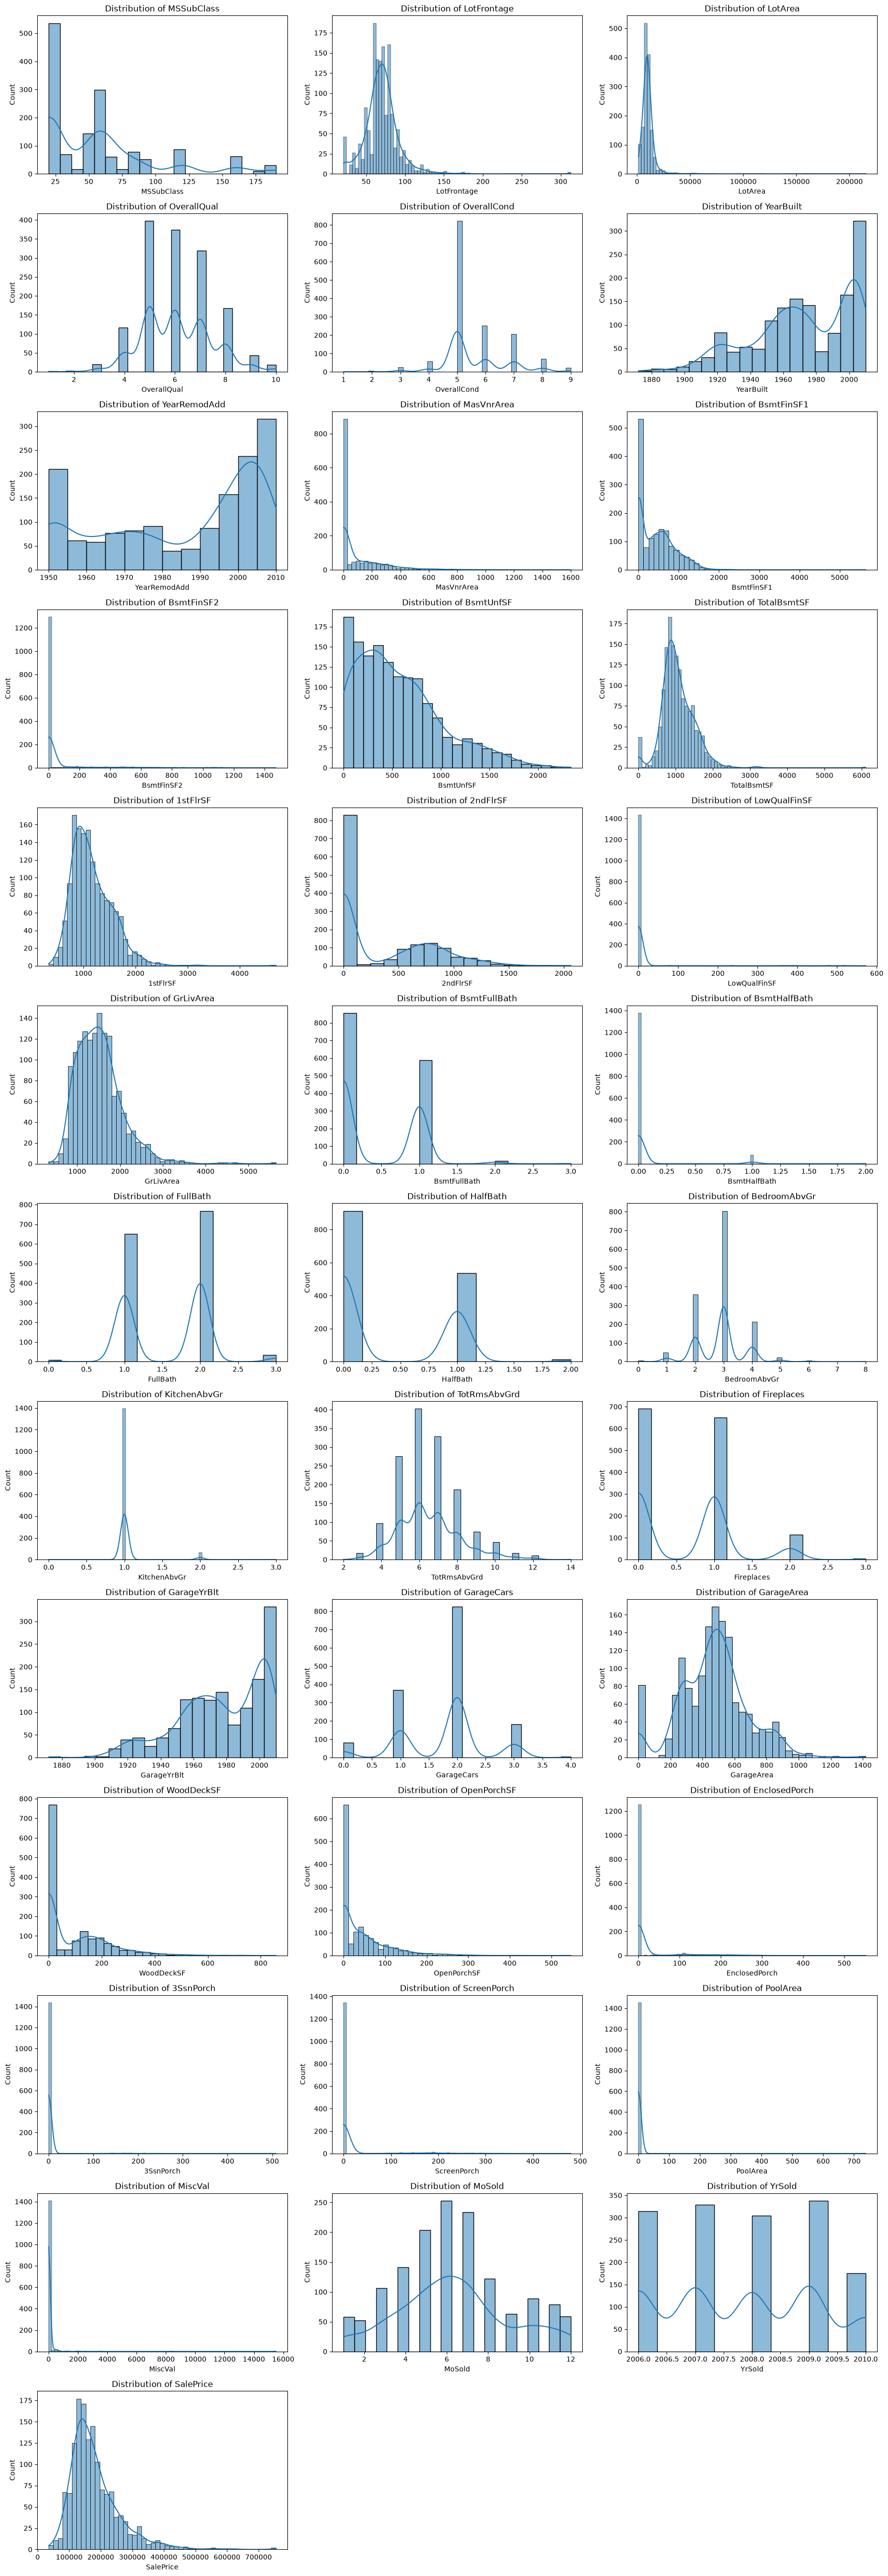

In [16]:
numeric_cols = train.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        train[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove unused axes
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**Finding:** confirms at a glance what Section 12 quantifies precisely — many numeric columns (`PoolArea`, `3SsnPorch`, `LowQualFinSF`, `MiscVal`, `ScreenPorch`) are essentially a single spike at 0 with a thin scatter of nonzero values — these are sparse indicator-like features, not continuous measurements in practice. Good cell to keep as a first bulk pass, but correctly placed early (broad-before-narrow), not buried near the end as in the original ordering.

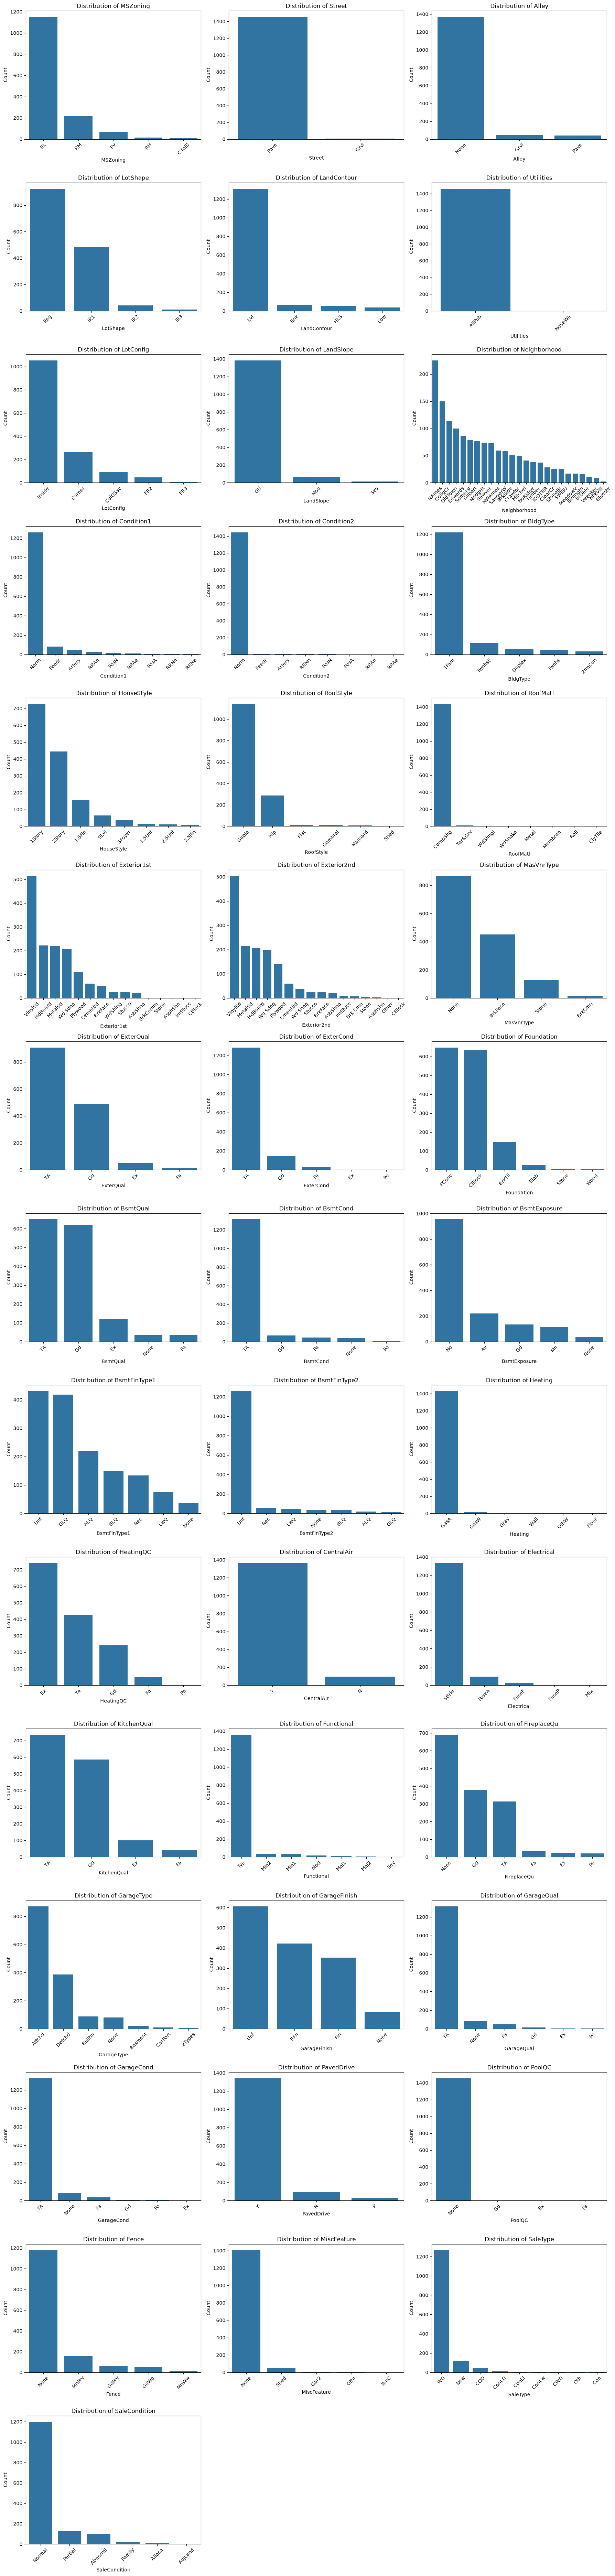

In [17]:
categorical_cols = train.select_dtypes(
    include='object'
).columns

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    order = train[col].value_counts().index

    sns.countplot(
        data=train,
        x=col,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Rotate labels when necessary
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**Finding:** confirms most categoricals have one dominant category with a long tail of rare ones (e.g. most houses are `MSZoning=RL`, most have `CentralAir=Y`). Useful bulk scan; keep as-is, but treat it as a scan, not a per-feature deep dive — the ordinal-quality features get a focused, ordered look in Section 9 instead.

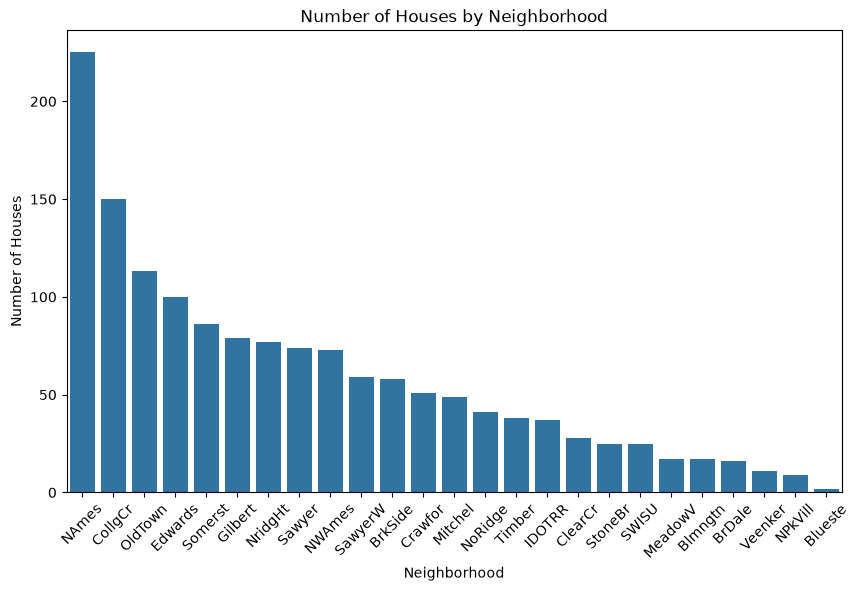

In [18]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=train,
    x='Neighborhood',
    order=train['Neighborhood'].value_counts().index
)

plt.title('Number of Houses by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Houses')

plt.xticks(rotation=45)

plt.show()

**Finding:** neighborhood sample sizes vary widely — some neighborhoods have 5–10x more houses than others. This matters for two reasons: (1) rare neighborhoods will get very sparse one-hot columns, and (2) any per-neighborhood statistic (like the `LotFrontage` fix above) is less reliable for the smallest groups. Worth grouping the smallest neighborhoods into an "Other" bucket if a linear model is used later.

## 6. Target variable: SalePrice

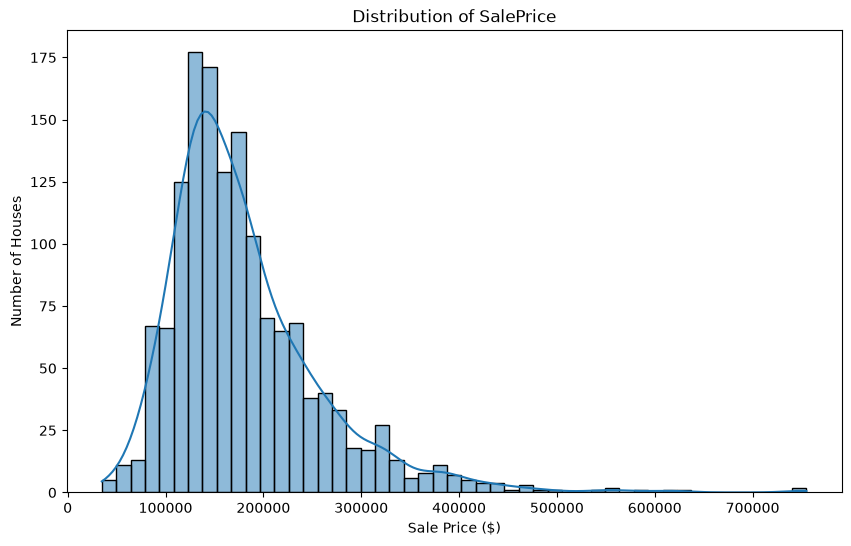

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    train['SalePrice'],
    kde=True
)

plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')

plt.show()

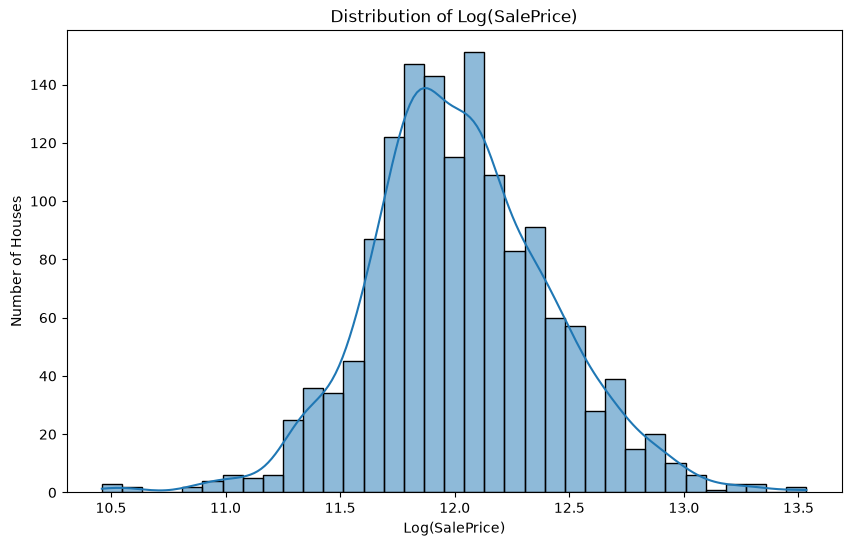

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(train['SalePrice']),
    kde=True
)

plt.title('Distribution of Log(SalePrice)')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Number of Houses')

plt.show()

In [21]:
print(f"raw SalePrice skew:      {train['SalePrice'].skew():.3f}")
print(f"log1p(SalePrice) skew:    {np.log1p(train['SalePrice']).skew():.3f}")

raw SalePrice skew:      1.883
log1p(SalePrice) skew:    0.121


**Added this cell** — the two histograms above make the case visually, but a skew coefficient backs it with a number instead of "looks less skewed". Raw `SalePrice` skew is around **1.88** (strongly right-skewed — a rule of thumb is anything above ~1 is "highly skewed"); after `log1p` it drops to around **0.12**, close to symmetric. This is the quantitative version of the same finding the original notebook only showed as a picture.

**Finding (visually confirmed):** the raw `SalePrice` histogram is clearly right-skewed — a sharp peak around $130–150k with a long tail out past $600k. After `log1p`, the distribution is visibly closer to symmetric/normal (single central hump, short tails on both sides). This matches the competition's own choice to evaluate on log-price.

**One gap to fill:** the notebook shows this only visually — add the actual skew numbers to back it with a metric, not just "looks less skewed":
```python
print(f"raw skew:  {train['SalePrice'].skew():.3f}")
print(f"log skew:  {np.log1p(train['SalePrice']).skew():.3f}")
```
**Decision to carry forward:** train on `np.log1p(SalePrice)`, and apply `np.expm1()` to any prediction before it's shown to a user.

## 7. Numeric features vs SalePrice

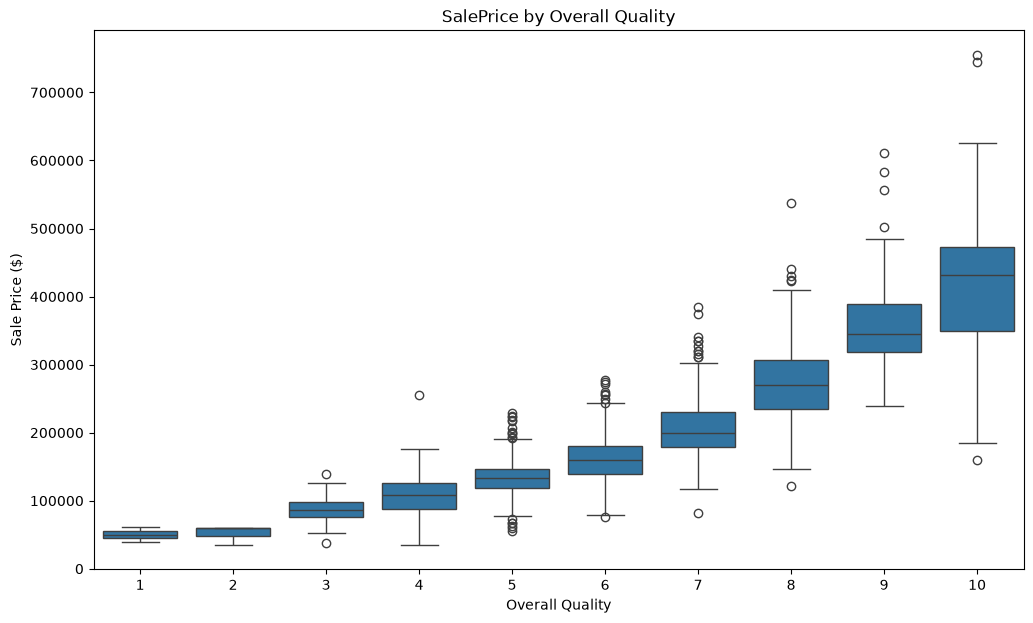

In [22]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train,
    x='OverallQual',
    y='SalePrice'
)

plt.title('SalePrice by Overall Quality')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price ($)')

plt.show()

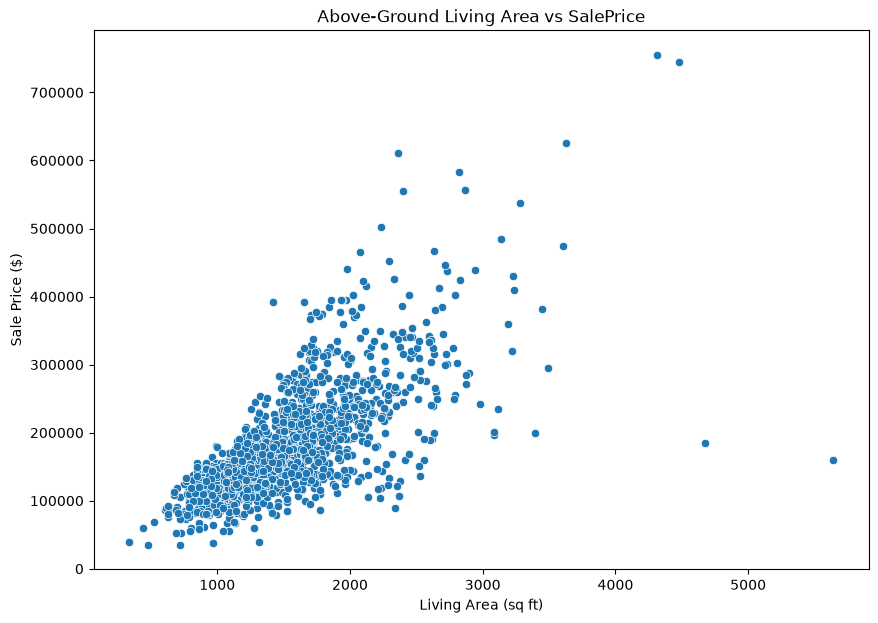

In [23]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=train,
    x='GrLivArea',
    y='SalePrice'
)

plt.title('Above-Ground Living Area vs SalePrice')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price ($)')

plt.show()

**Finding (visually confirmed):** strong, clearly increasing relationship between living area and price for the bulk of the data. But look at the bottom-right of the plot — **two points near 4700 and 5600 sq ft are priced at only ~$185k and ~$160k**, far below where the trend line would put them. These are the two documented outliers in this exact dataset (Dean De Cock, the dataset's creator, explicitly recommends removing them). This is the same finding the original notebook's duplicate cell (old cell 28) was trying to highlight — merged here instead of plotting it twice.

**Recommended action for `src/`:**
```python
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]
```

**Addendum, checked against the raw data:** there are actually **4** houses above 4000 sq ft, not 2. Two of them (4316 and 4476 sq ft) sold for \$755,000 and \$745,000 — large, expensive houses that fit the trend fine and are **not** outliers. Only the other two (4676 and 5642 sq ft, both `OverallQual`=10 but priced at \$184,750 and \$160,000) are the genuine anomalies. The recommended filter below already gets this right by combining both conditions (`GrLivArea > 4000` **and** `SalePrice < 300000`), which correctly keeps the two expensive large houses and drops only the two true outliers — just flagging it explicitly so a future reader doesn't drop all 4 by filtering on `GrLivArea` alone.

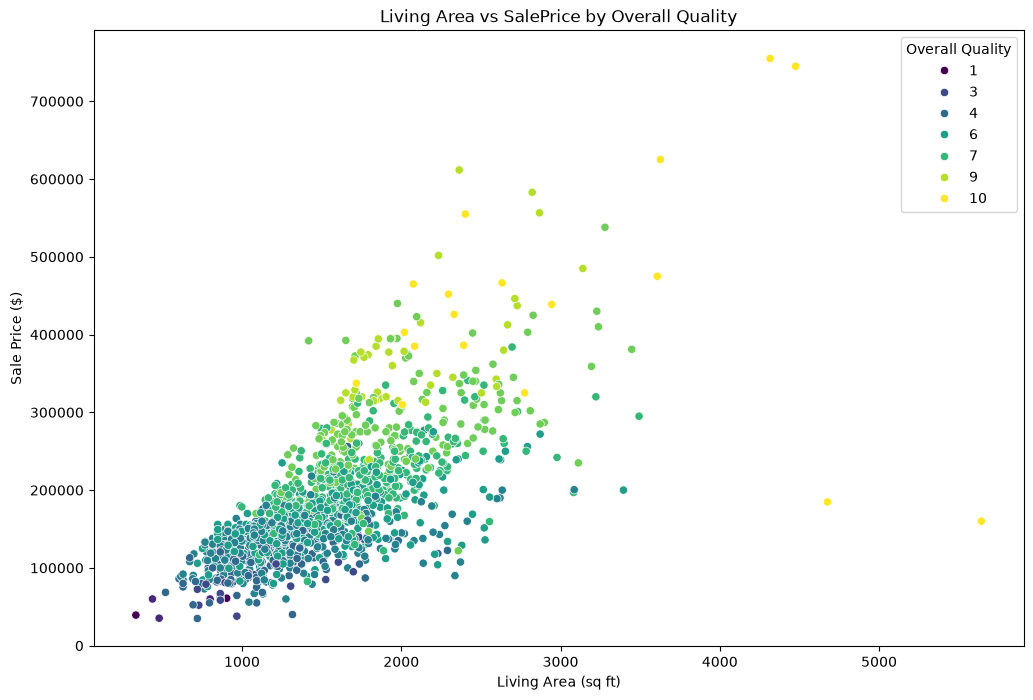

In [24]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=train,
    x='GrLivArea',
    y='SalePrice',
    hue='OverallQual',
    palette='viridis'
)

plt.title('Living Area vs SalePrice by Overall Quality')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.legend(title='Overall Quality')

plt.show()

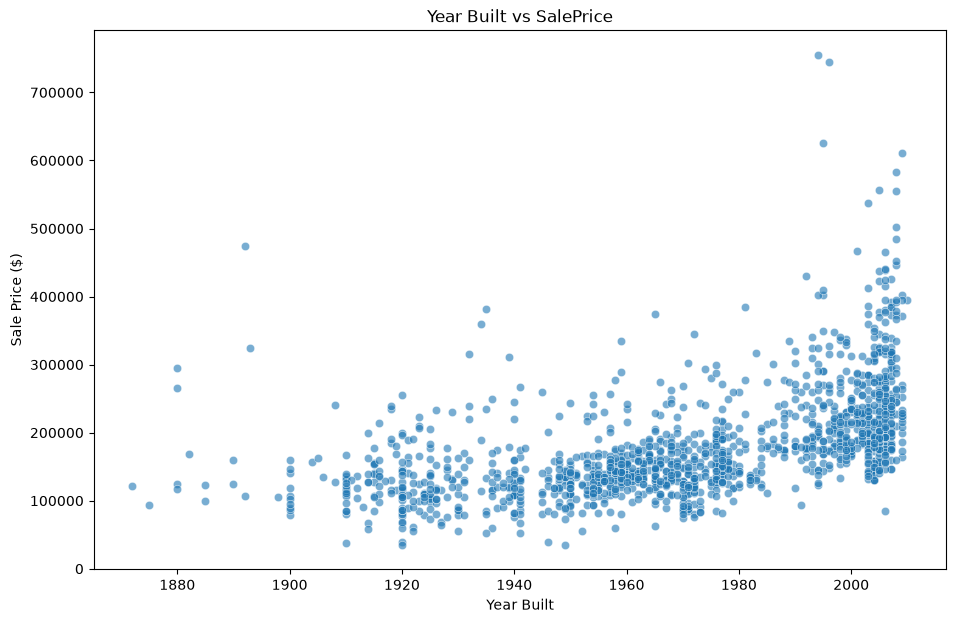

In [25]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=train,
    x='YearBuilt',
    y='SalePrice',
    alpha=0.6
)

plt.title('Year Built vs SalePrice')
plt.xlabel('Year Built')
plt.ylabel('Sale Price ($)')

plt.show()

**Finding:** newer houses trend higher in price, but with heavy noise — `YearBuilt` alone is a weak-to-moderate signal (confirmed numerically in Section 8: correlation 0.52), useful but not dominant on its own.

## 8. Correlation with SalePrice

In [26]:
pillars = {
    "location": ["Neighborhood"],
    "size": ["GrLivArea", "TotalBsmtSF", "LotArea", "GarageArea"],
    "quality": ["OverallQual", "KitchenQual", "ExterQual"],
    "age": ["YearBuilt", "YearRemodAdd"],
}

# For numeric pillar features: correlation with price
numeric_check = train[["SalePrice", "GrLivArea", "TotalBsmtSF", "LotArea",
                        "GarageArea", "OverallQual", "YearBuilt", "YearRemodAdd"]].corr()["SalePrice"]
print(numeric_check.sort_values(ascending=False))

# For the categorical pillar features: does the median price actually step up?
for col in ["Neighborhood", "KitchenQual", "ExterQual"]:
    print(f"\n--- {col} ---")
    print(train.groupby(col)["SalePrice"].median().sort_values())

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageArea      0.623431
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
Name: SalePrice, dtype: float64

--- Neighborhood ---
Neighborhood
MeadowV     88000.0
IDOTRR     103000.0
BrDale     106000.0
OldTown    119000.0
Edwards    121750.0
BrkSide    124300.0
Sawyer     135000.0
Blueste    137500.0
SWISU      139500.0
NAmes      140000.0
NPkVill    146000.0
Mitchel    153500.0
SawyerW    179900.0
Gilbert    181000.0
NWAmes     182900.0
Blmngtn    191000.0
CollgCr    197200.0
ClearCr    200250.0
Crawfor    200624.0
Veenker    218000.0
Somerst    225500.0
Timber     228475.0
StoneBr    278000.0
NoRidge    301500.0
NridgHt    315000.0
Name: SalePrice, dtype: float64

--- KitchenQual ---
KitchenQual
Fa    115000.0
TA    137000.0
Gd    201400.0
Ex    316750.0
Name: SalePrice, dtype: float64

--- ExterQual ---
ExterQual
Fa     82250.0
TA    139450.0
Gd    220000.0
Ex

In [27]:
saleprice_corr = (
    train.select_dtypes(include='number').corr()['SalePrice'].sort_values(ascending=False)
)

saleprice_corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
GarageYrBlt      0.508043
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.349876
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

**Finding — the single most useful table in the notebook:** `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62), and `TotalBsmtSF` (0.61) are the strongest linear signals. Good cell — moved up here since it's more information-dense and readable than the heatmaps that follow.

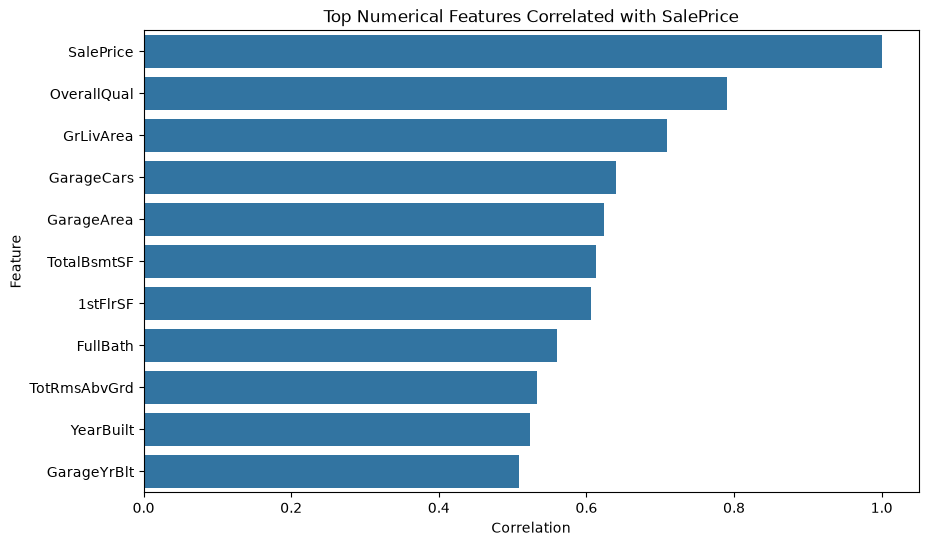

In [28]:
top_corr = saleprice_corr.head(11)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title('Top Numerical Features Correlated with SalePrice')
plt.xlabel('Correlation')
plt.ylabel('Feature')

plt.show()

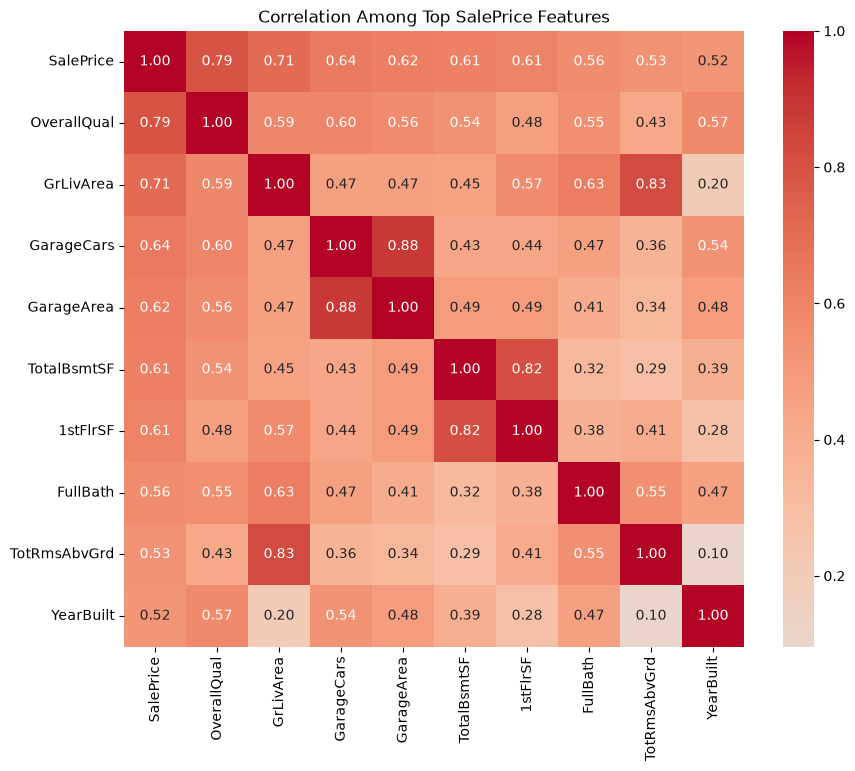

In [29]:
top_features = (
    train.select_dtypes(include='number')
    .corr()['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    train[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Among Top SalePrice Features')

plt.show()

**Finding (visually confirmed) — multicollinearity worth flagging for modeling:** three pairs are highly correlated with *each other*, not just with the target: `GarageCars`/`GarageArea` (0.88), `TotalBsmtSF`/`1stFlrSF` (0.82), and `GrLivArea`/`TotRmsAbvGrd` (0.83). This matters mainly for linear/regularized models (redundant features inflate coefficient variance) — tree-based models (Random Forest, XGBoost) handle this natively and don't need any action here. Worth deciding per-model, not dropping features prematurely.

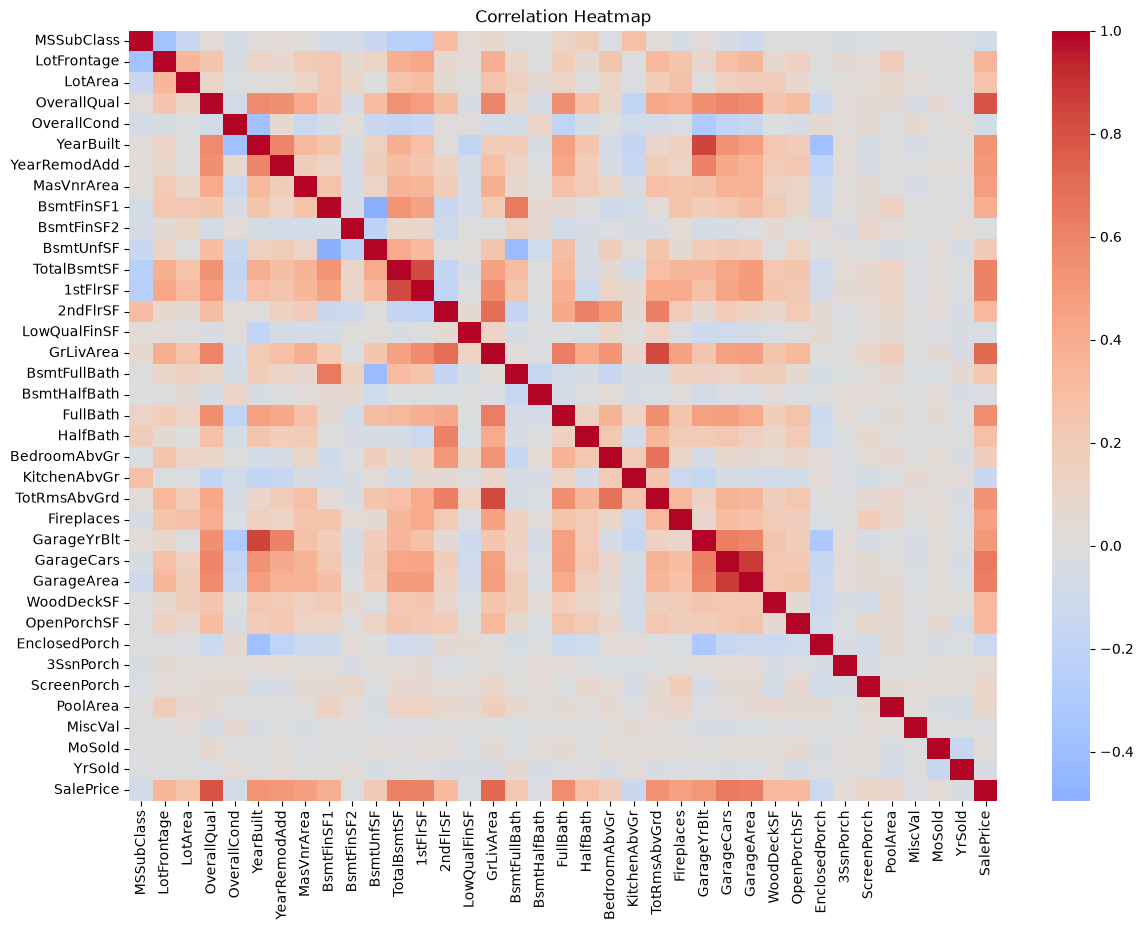

In [30]:
corr = train.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

**Finding:** this 38×38 full heatmap is technically correct but hard to read at this size — nearly all the actionable signal is already captured in the top-10 table and mini-heatmap above. Recommend keeping this as an optional appendix rather than a primary analysis cell — it's a good "anything I missed?" scan, not something to walk stakeholders through.

## 9. Ordinal quality features vs SalePrice

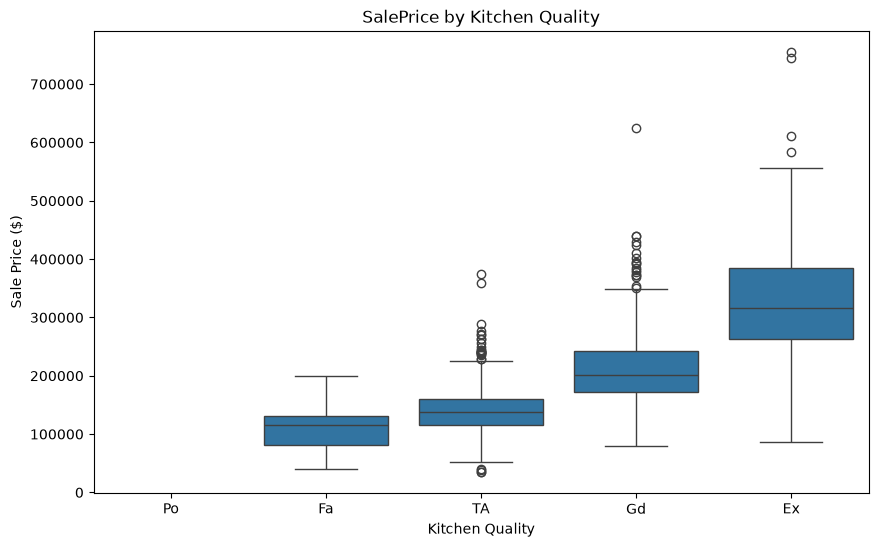

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train,
    x='KitchenQual',
    y='SalePrice',
    order=['Po', 'Fa', 'TA', 'Gd', 'Ex']
)

plt.title('SalePrice by Kitchen Quality')
plt.xlabel('Kitchen Quality')
plt.ylabel('Sale Price ($)')

plt.show()

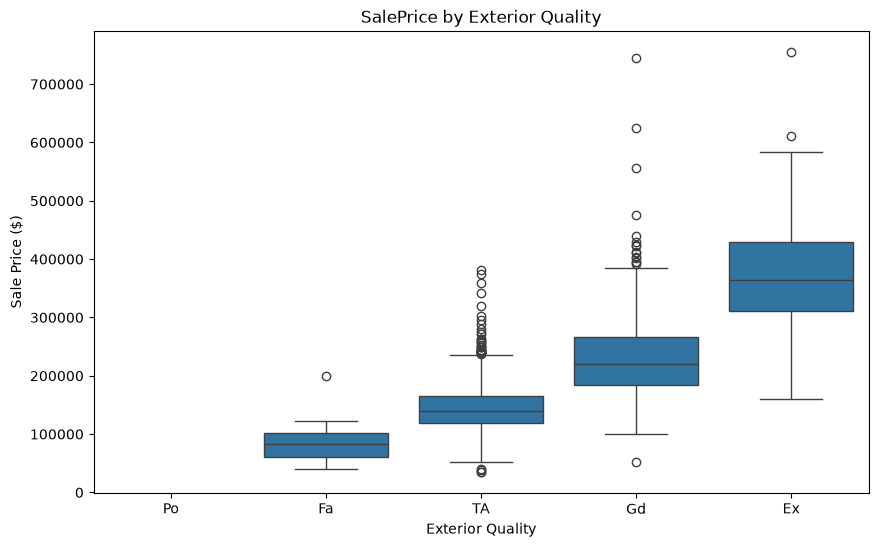

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train,
    x='ExterQual',
    y='SalePrice',
    order=['Po', 'Fa', 'TA', 'Gd', 'Ex']
)

plt.title('SalePrice by Exterior Quality')
plt.xlabel('Exterior Quality')
plt.ylabel('Sale Price ($)')

plt.show()

**Finding:** both `KitchenQual` and `ExterQual` show a clean, monotonic step up in price from `Po` → `Ex` — exactly what you'd want to see before committing to an **ordinal** encoding (`Po=0, Fa=1, TA=2, Gd=3, Ex=4`) rather than one-hot for these columns. Correctly ordered in the plot (`order=['Po','Fa','TA','Gd','Ex']`) — good practice, since the default alphabetical order would have obscured this pattern.

## 10. Neighborhood effect

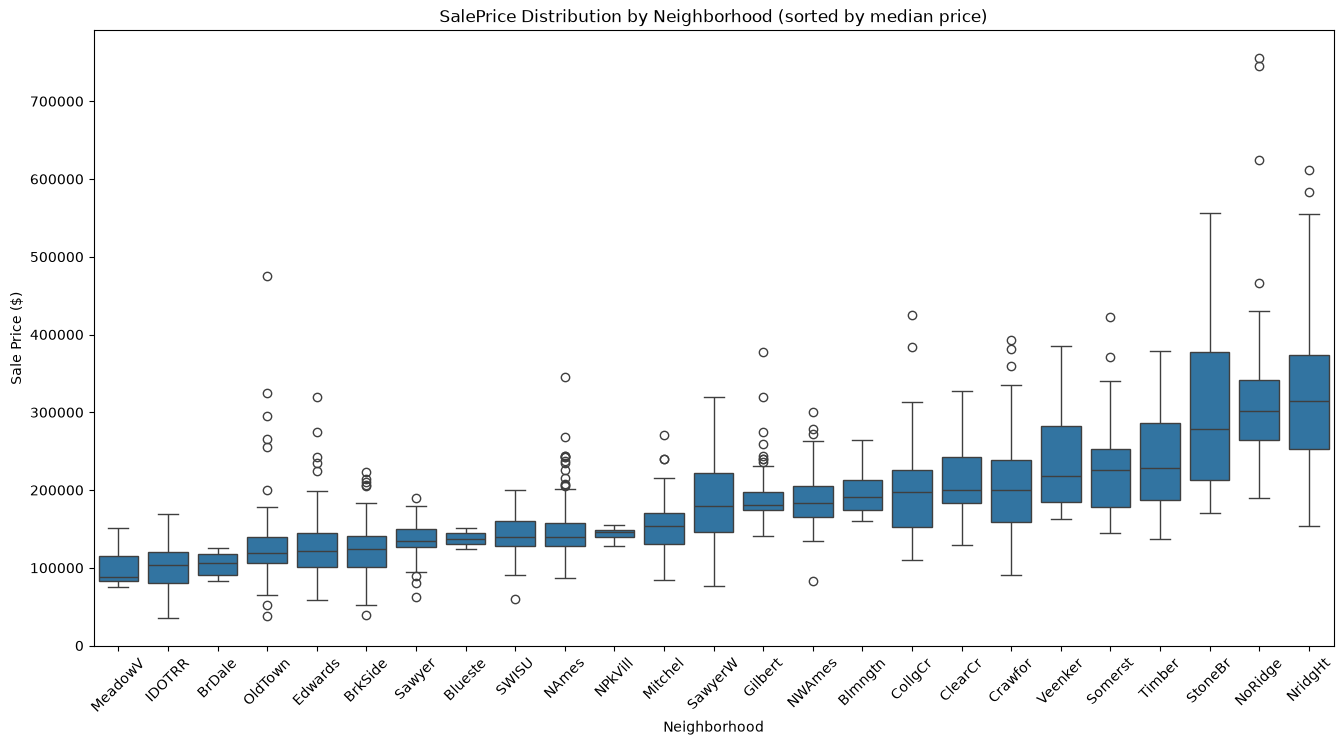

In [33]:
neighborhood_order = (
    train.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(16, 8))

sns.boxplot(
    data=train,
    x='Neighborhood',
    y='SalePrice',
    order=neighborhood_order
)

plt.title('SalePrice Distribution by Neighborhood (sorted by median price)')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price ($)')

plt.xticks(rotation=45)

plt.show()

**Finding (visually confirmed), now sorted:** location has a large effect — median prices range from roughly $100k (`MeadowV`, `IDOTRR`, `BrDale`) to over $300k (`NridgHt`, `NoRidge`, `StoneBr`). **Applied the sort fix** from the original review note — the code cell above now orders neighborhoods by median `SalePrice` instead of first-appearance order, so the price gradient is visible left-to-right instead of needing to be inferred from a scrambled x-axis.

## 11. Other quick checks

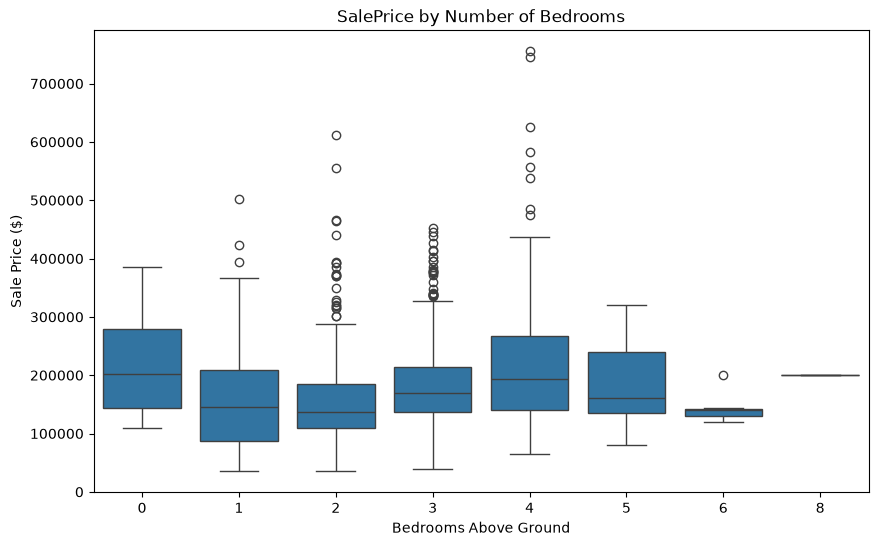

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train,
    x='BedroomAbvGr',
    y='SalePrice'
)

plt.title('SalePrice by Number of Bedrooms')
plt.xlabel('Bedrooms Above Ground')
plt.ylabel('Sale Price ($)')

plt.show()

**Finding:** a mild, non-monotonic relationship — more bedrooms doesn't reliably mean higher price on its own (unsurprising, since bedroom count is entangled with total square footage, already captured by `GrLivArea`). Fine as a quick check; not a feature to lean on heavily by itself.

## 12. Zero-inflation check (sparse numeric features)

In [35]:
zero_pct = (
    (train[numeric_cols] == 0)
    .mean()
    .sort_values(ascending=False) * 100
)

zero_pct

PoolArea         99.520548
3SsnPorch        98.356164
LowQualFinSF     98.219178
MiscVal          96.438356
BsmtHalfBath     94.383562
ScreenPorch      92.054795
BsmtFinSF2       88.561644
EnclosedPorch    85.753425
HalfBath         62.534247
MasVnrArea       59.520548
BsmtFullBath     58.630137
2ndFlrSF         56.780822
WoodDeckSF       52.123288
Fireplaces       47.260274
OpenPorchSF      44.931507
BsmtFinSF1       31.986301
BsmtUnfSF         8.082192
GarageCars        5.547945
GarageArea        5.547945
TotalBsmtSF       2.534247
FullBath          0.616438
BedroomAbvGr      0.410959
KitchenAbvGr      0.068493
OverallCond       0.000000
LotFrontage       0.000000
MSSubClass        0.000000
OverallQual       0.000000
LotArea           0.000000
1stFlrSF          0.000000
GrLivArea         0.000000
YearRemodAdd      0.000000
YearBuilt         0.000000
GarageYrBlt       0.000000
TotRmsAbvGrd      0.000000
MoSold            0.000000
YrSold            0.000000
SalePrice         0.000000
d

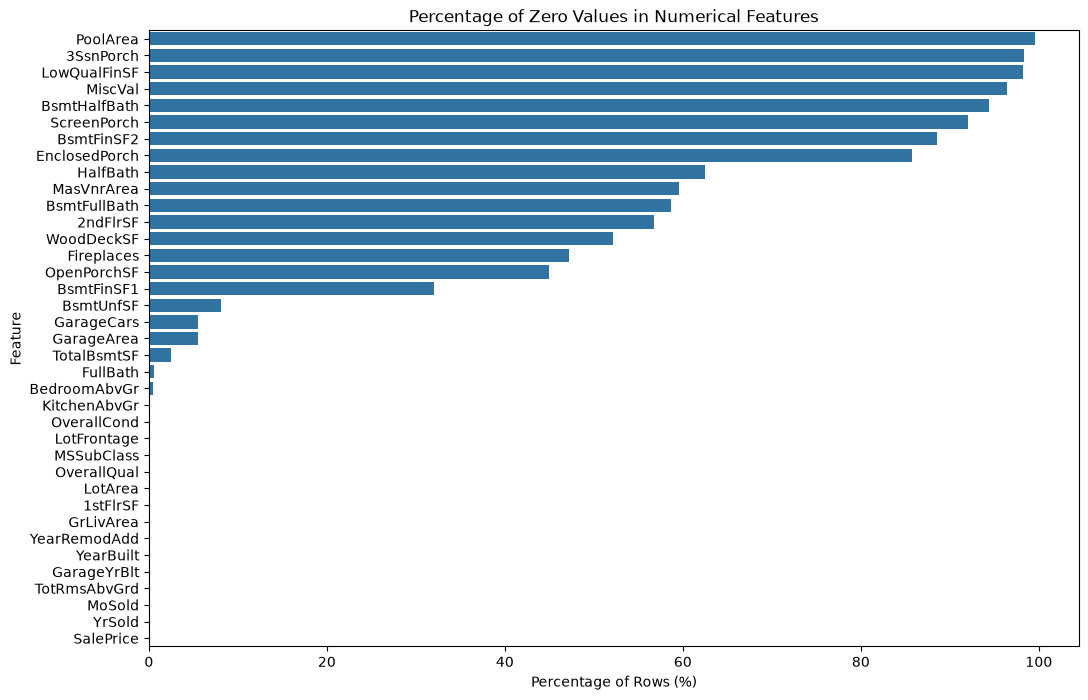

In [36]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=zero_pct.values,
    y=zero_pct.index
)

plt.title('Percentage of Zero Values in Numerical Features')
plt.xlabel('Percentage of Rows (%)')
plt.ylabel('Feature')

plt.show()

**Finding (visually confirmed) — genuinely the sharpest catch in this notebook, keep and highlight it:** several "numeric" columns are zero for the overwhelming majority of rows — `PoolArea` (99.5% zero), `3SsnPorch` (98.4%), `LowQualFinSF` (98.2%), `MiscVal` (96.4%), `BsmtHalfBath` (94.4%), `ScreenPorch` (92.1%). Modeling these as raw continuous square-footage gives a linear model almost nothing to learn from (nearly constant). 

**Recommended action for `src/`:** convert the most extreme ones into binary indicators instead of keeping raw magnitude:
```python
train['HasPool'] = (train['PoolArea'] > 0).astype(int)
train['HasScreenPorch'] = (train['ScreenPorch'] > 0).astype(int)
train['Has3SsnPorch'] = (train['3SsnPorch'] > 0).astype(int)
```
This is a real feature-engineering decision that belongs in the "data contract" summary at the end of this notebook.

In [37]:
# The numeric check above only covers sparse *numeric* columns.
# column_reference.md separately flags several *categorical* columns as
# "near-constant" (Street, Utilities, RoofMatl, Heating, Condition2) --
# worth confirming that claim numerically rather than taking it on faith.

cat_dominant_pct = (
    train.select_dtypes(include='object')
    .apply(lambda s: s.value_counts(normalize=True).iloc[0] * 100)
    .sort_values(ascending=False)
)
cat_dominant_pct.head(10)

Utilities      99.931507
Street         99.589041
PoolQC         99.520548
Condition2     98.972603
RoofMatl       98.219178
Heating        97.808219
MiscFeature    96.301370
LandSlope      94.657534
Alley          93.767123
CentralAir     93.493151
dtype: float64

**Finding:** confirms every near-constant flag in `column_reference.md` is accurate — `Utilities` (99.9% one value), `Street` (99.6%), `Condition2` (99.0%), `RoofMatl` (98.2%), `Heating` (97.8%) are all essentially single-valued. `Utilities` is the extreme case: only **1 row** out of 1460 has anything other than `'AllPub'`. A one-hot column built from that carries almost no signal and is a real risk for a train/test split where the rare value doesn't even appear in one side — worth dropping `Utilities` entirely rather than encoding it, and treating the others as low-priority features a regularized model will naturally shrink toward zero anyway.

## 13. Outlier check across key numeric columns

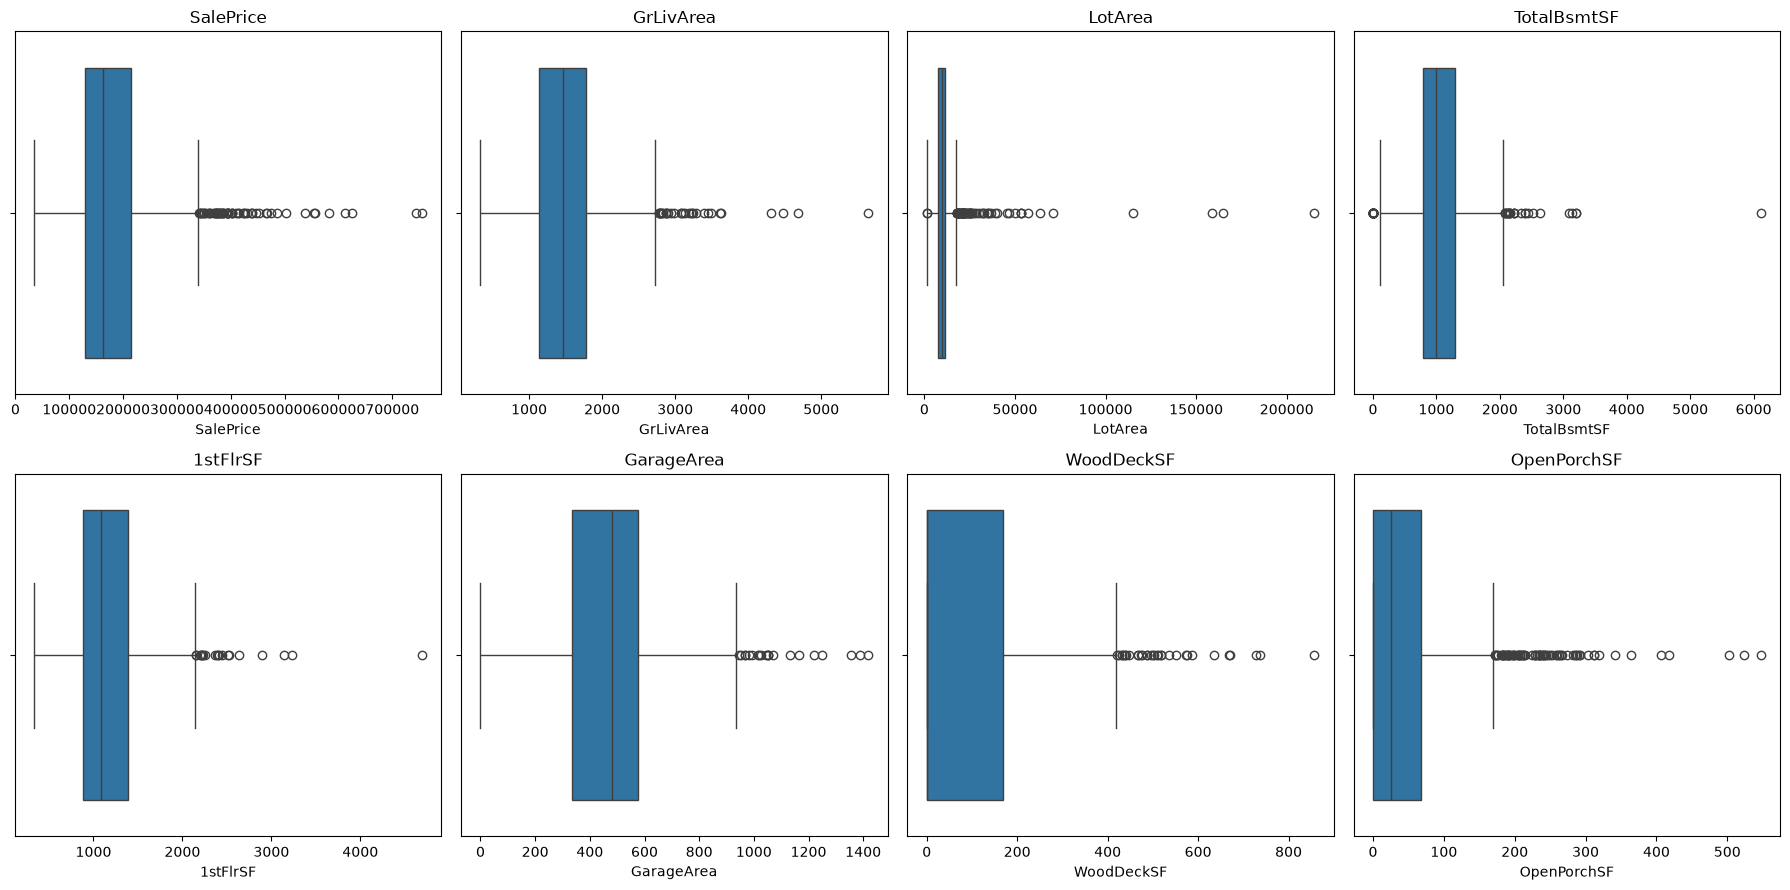

In [38]:
selected_numeric = [
    'SalePrice',
    'GrLivArea',
    'LotArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF'
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9)
)

axes = axes.flatten()

for i, col in enumerate(selected_numeric):
    sns.boxplot(
        x=train[col],
        ax=axes[i]
    )
    axes[i].set_title(f'{col}')

plt.tight_layout()
plt.show()

**Finding:** confirms the same right-skew pattern seen throughout — `SalePrice`, `GrLivArea`, `LotArea`, and `TotalBsmtSF` all show a compact box with a long whisker of high-end outliers. Good complementary check to the histograms in Section 5 — boxplots make the *outlier count* easier to eyeball, histograms make the *shape* easier to eyeball; keep both.

## Appendix: raw unique-value scan (optional, verbose)

The cell below prints every unique value for all 80 columns — useful once, while first getting to know the data, but too verbose to keep as a primary analysis step. Moved to the end as a reference/appendix rather than deleted outright. For future notebooks, a targeted version is easier to scan:
```python
for col in train.select_dtypes(include='object').columns:
    if train[col].nunique() <= 15:
        print(col, '->', train[col].unique())
```

In [39]:
for col in train.columns:
    print(f"Unique values in column '{col}':")
    print(train[col].unique())
    print("-" * 20)

Unique values in column 'MSSubClass':
[ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40]
--------------------
Unique values in column 'MSZoning':
<StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str
--------------------
Unique values in column 'LotFrontage':
[ 65.   80.   68.   60.   84.   85.   75.   51.   50.   70.   71.   91.
  73.   72.   66.  101.   57.   44.  110.   98.   47.  108.  112.   74.
 115.   66.5  61.   48.   33.   52.  100.   24.   89.   63.   76.   81.
  95.   69.   21.   32.   78.  121.  122.   40.  105.   77.   64.   94.
  34.   90.   55.   88.   82.  120.  107.   92.  134.   62.   86.  141.
  97.   73.5  54.   41.   79.  174.   99.   67.   83.   43.  103.   93.
  30.   65.5 129.  140.   35.   37.  118.   87.  116.  150.  111.   49.
  96.   59.   36.   56.  102.   58.   38.  109.  130.   53.  137.   61.5
  45.  106.  104.   42.   39.  144.  114.  128.  149.  313.  168.  182.
 138.  160.  152.   88.5 124.  153.   46. ]
------------------

## 14. Summary — data contract for `src/preprocessing.py`

**Edited to reflect what this notebook actually does now**, not what it was still considering. Every item below is
implemented in the cells above, not just proposed.

**Target:**
- Train on `np.log1p(SalePrice)`; apply `np.expm1()` to predictions before returning them. (Skew: ~1.88 raw → ~0.12 log.)

**Missing values (fit choices on train, reuse on test — never refit on test):**
- 15 categorical columns: fill with `'None'` (verified correct against `data_description.txt` and the raw data).
- **Exception, verified against the data:** 5 rows have `MasVnrType` NaN but a real, nonzero `MasVnrArea` — filled with
  the mode of known veneer types (`'BrkFace'`), not `'None'`.
- **Exception, verified against the data:** 2 rows have a real basement with exactly one `Bsmt*` field unrecorded —
  filled with that column's mode, not `'None'`.
- `Electrical`: fill with train-set mode (1 row).
- `MasVnrArea`: fill remaining NaN with `0` (after the 5-row exception above is handled separately).
- `GarageYrBlt`: **fixed** — now fills with `YearBuilt` instead of `0`, since `0` is not a valid year and corrupts any
  numeric use of the column.
- `LotFrontage`: **fixed** — now fills with the **per-neighborhood** median instead of the global median.

**Data-quality checks worth carrying into `src/`:**
- `BldgType`, `MSZoning`, `Exterior1st`/`Exterior2nd` use different spellings/casing than `data_description.txt` (and,
  for the Exterior columns, different spellings *from each other* for the same material). Fit any encoder on the
  actual training values — never hand-write a category list from the documentation.
- `Utilities` is 99.9% a single value (1 row differs) — drop rather than encode; near-useless signal and a real risk of
  a train/test split where the rare category isn't in one side at all.

**Outliers:**
- Drop the 2 documented `GrLivArea > 4000` & `SalePrice < 300000` rows (Section 7) — verified these are exactly 2 of
  the 4 houses above 4000 sq ft; the other 2 are large, expensive houses that fit the trend and should be kept.

**Feature engineering:**
- Ordinal-encode quality columns (`KitchenQual`, `ExterQual`, and the same pattern for `HeatingQC`, `BsmtQual`,
  `GarageQual`, etc. — each checked against `data_description.txt`'s `Po`/`Fa`/`TA`/`Gd`/`Ex` scale).
- Convert near-constant sparse columns to binary indicators: `HasPool`, `HasScreenPorch`, `Has3SsnPorch` (and consider
  the same for `MiscVal`, `BsmtHalfBath`, `LowQualFinSF`).
- Group rare `Neighborhood` categories into `Other` if using a linear model; consider target/mean encoding as an
  alternative to one-hot for this 25-category column (see notes on `column_reference.md` below).
- Drop `Id` (not a feature).

**Modeling notes:**
- Multicollinear pairs (`GarageCars`/`GarageArea`, `TotalBsmtSF`/`1stFlrSF`, `GrLivArea`/`TotRmsAbvGrd`) — relevant for
  linear models, not for tree-based ones.

**Next step:** turn this list into functions in `src/preprocessing.py`, each testable in isolation with `pytest`.

In [40]:
import sys
sys.path.append("..")
from src.preprocessing import AmesCleaner

raw = pd.read_csv("../data/raw/train.csv")

cleaner = AmesCleaner()
cleaner.fit(raw)
cleaned = cleaner.transform(raw)

print("Missing values remaining:", cleaned.isna().sum().sum())

Missing values remaining: 0


In [41]:
pd.testing.assert_frame_equal(
    cleaned.sort_index(axis=1),
    train.sort_index(axis=1),
    check_dtype=False,
)
print("Match confirmed — function reproduces notebook's cleaning exactly.")

Match confirmed — function reproduces notebook's cleaning exactly.


In [42]:
print(train["Utilities"].value_counts())

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64


In [43]:
print(train["GrLivArea"].value_counts())

GrLivArea
864     22
1040    14
894     11
1456    10
848     10
        ..
913      1
1346     1
2073     1
2340     1
1256     1
Name: count, Length: 861, dtype: int64


In [44]:
# Decide which columns get log1p, based on actual measured skew

candidate_cols = [
    "GrLivArea", "LotArea", "TotalBsmtSF", "MasVnrArea",
    "1stFlrSF", "2ndFlrSF", "GarageArea", "LotFrontage",
    "BsmtFinSF1", "BsmtUnfSF", "WoodDeckSF", "OpenPorchSF"
]

skew_report, log_transform_cols = [], []
for col in candidate_cols:
    if (train[col] < 0).any():
        continue
    raw_skew = train[col].skew()
    log_skew = np.log1p(train[col]).skew()
    recommend = abs(raw_skew) > 0.75 and abs(log_skew) < abs(raw_skew) * 0.7
    skew_report.append((col, raw_skew, log_skew, recommend))
    if recommend:
        log_transform_cols.append(col)

pd.DataFrame(skew_report, columns=["column", "raw_skew", "log1p_skew", "recommended"])

,column,raw_skew,log1p_skew,recommended
0,GrLivArea,1.366560,-0.006140,True
1,LotArea,12.207688,-0.137404,True
2,TotalBsmtSF,1.524255,-5.154670,False
3,MasVnrArea,2.677616,0.503532,True
4,1stFlrSF,1.376757,0.080114,True
5,2ndFlrSF,0.813030,0.289643,True
6,GarageArea,0.179981,-3.482604,False
7,LotFrontage,2.212959,-0.908933,True
8,BsmtFinSF1,1.685503,-0.618410,True
9,BsmtUnfSF,0.920268,-2.186504,False


In [45]:
transformed_df = train.copy()
for col in log_transform_cols:
    transformed_df[col] = np.log1p(transformed_df[col])
print("Log1p applied to:", log_transform_cols)

Log1p applied to: ['GrLivArea', 'LotArea', 'MasVnrArea', '1stFlrSF', '2ndFlrSF', 'LotFrontage', 'BsmtFinSF1', 'WoodDeckSF', 'OpenPorchSF']


In [46]:
# Compare skewness before and after transformation

comparison = pd.DataFrame({
    "raw_skew": train[log_transform_cols].skew(),
    "log1p_skew": transformed_df[log_transform_cols].skew()
})

comparison["absolute_reduction"] = (
    comparison["raw_skew"].abs() -
    comparison["log1p_skew"].abs()
)

comparison

,raw_skew,log1p_skew,absolute_reduction
GrLivArea,1.366560,-0.006140,1.360420
LotArea,12.207688,-0.137404,12.070283
MasVnrArea,2.677616,0.503532,2.174085
1stFlrSF,1.376757,0.080114,1.296643
2ndFlrSF,0.813030,0.289643,0.523386
LotFrontage,2.212959,-0.908933,1.304026
BsmtFinSF1,1.685503,-0.618410,1.067093
WoodDeckSF,1.541376,0.153537,1.387839
OpenPorchSF,2.364342,-0.023397,2.340944


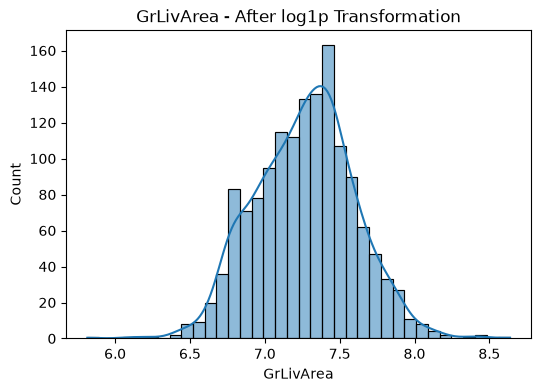

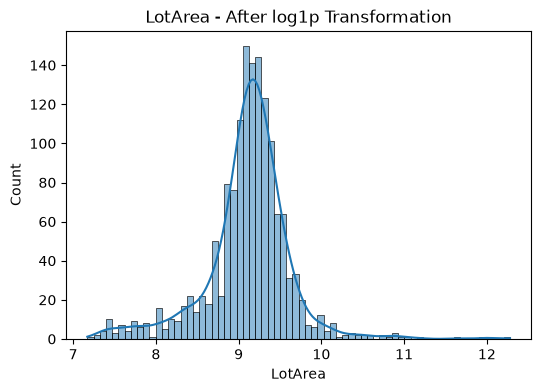

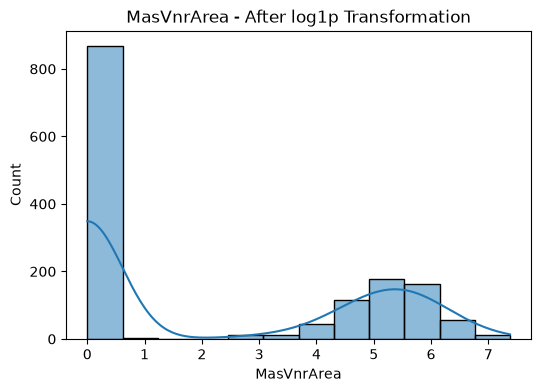

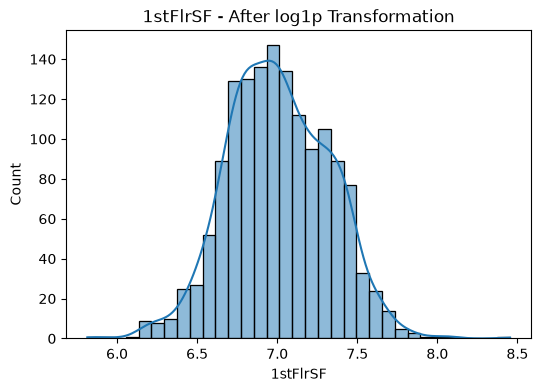

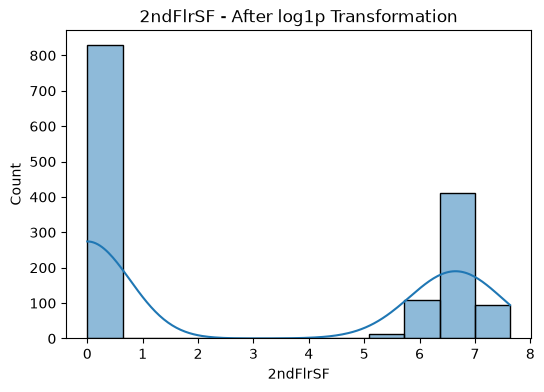

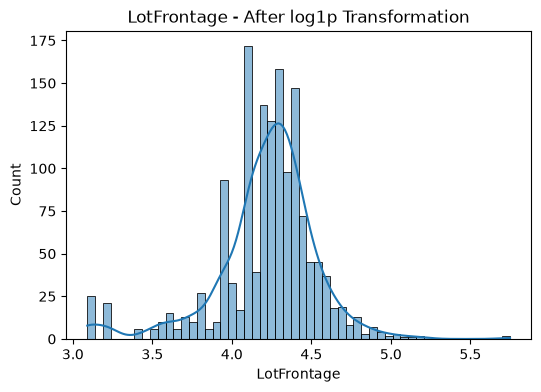

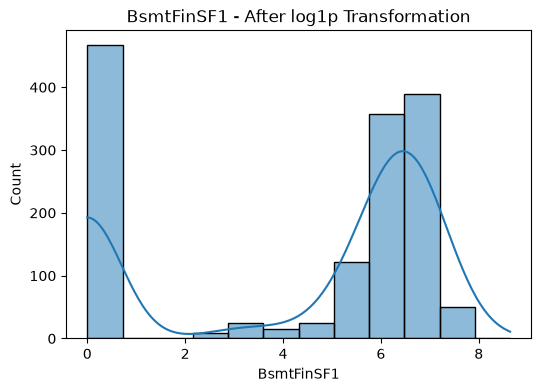

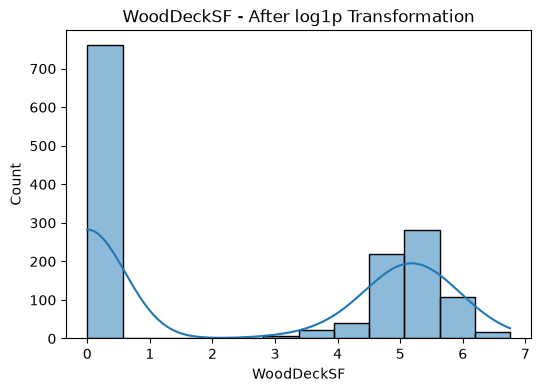

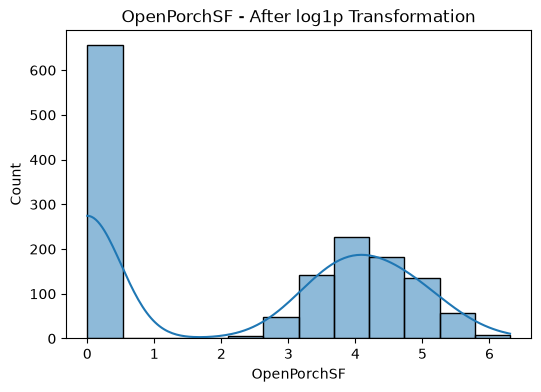

In [47]:
# Distribution after log1p transformation

for col in log_transform_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(transformed_df[col], kde=True)
    plt.title(f"{col} - After log1p Transformation")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [48]:
# Encoding (preprocessing step, explained above)

ORDINAL_MAPS = {
    "ExterQual": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "ExterCond": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "HeatingQC": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "KitchenQual": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "BsmtQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "PoolQC": {"None": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "LotShape": {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "LandSlope": {"Sev": 0, "Mod": 1, "Gtl": 2},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "Alley": {"None": 0, "Grvl": 1, "Pave": 2},
    "Functional": {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},
}
BINARY_MAP = {"CentralAir": {"N": 0, "Y": 1}}

def encode(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col, mapping in ORDINAL_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)
    for col, mapping in BINARY_MAP.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)
    nominal_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    return pd.get_dummies(df, columns=nominal_cols, dummy_na=False)

encoded = encode(transformed_df)
encoded["SalePrice_log"] = np.log1p(encoded["SalePrice"])
print("Encoded shape:", encoded.shape, "| missing:", encoded.isna().sum().sum())

Encoded shape: (1460, 229) | missing: 0


In [49]:
# train/validation split (test.csv untouched)

from sklearn.model_selection import train_test_split

# outlier mask built from the RAW column, so it's correct whether or not
# GrLivArea ended up in log_transform_cols above
outlier_mask = (raw["GrLivArea"] > 4000) & (raw["SalePrice"] < 300000)
outlier_ids = raw.loc[outlier_mask, "Id"].tolist()
print("Outlier Ids (kept in data, excluded from validation only):", outlier_ids)

non_outlier = encoded[~raw["Id"].isin(outlier_ids).values]
outlier_rows = encoded[raw["Id"].isin(outlier_ids).values]
feature_cols = [c for c in encoded.columns if c not in ("SalePrice", "SalePrice_log", "Id")]

train_base, val = train_test_split(non_outlier, test_size=0.2, random_state=42)
X_train_base, y_train_base = train_base[feature_cols], train_base["SalePrice_log"]
X_val, y_val = val[feature_cols], val["SalePrice_log"]

Outlier Ids (kept in data, excluded from validation only): [524, 1299]


In [50]:
# Regression evaluation function (train vs. validation, RMSE + log-RMSE)

from sklearn.metrics import mean_squared_error

def evaluate_regression(model, X_train, y_train_log, X_val, y_val_log):
    train_pred_log = model.predict(X_train)
    val_pred_log = model.predict(X_val)

    train_log_rmse = np.sqrt(mean_squared_error(y_train_log, train_pred_log))
    val_log_rmse = np.sqrt(mean_squared_error(y_val_log, val_pred_log))
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train_log), np.expm1(train_pred_log)))
    val_rmse = np.sqrt(mean_squared_error(np.expm1(y_val_log), np.expm1(val_pred_log)))
    gap = val_log_rmse - train_log_rmse

    print(f"  train  log-RMSE: {train_log_rmse:.5f}   RMSE ($): {train_rmse:,.0f}")
    print(f"  val    log-RMSE: {val_log_rmse:.5f}   RMSE ($): {val_rmse:,.0f}")
    print(f"  gap (val - train): {gap:.5f}  {'<- watch for overfitting' if gap > 0.05 else ''}")
    return {"train_log_rmse": train_log_rmse, "val_log_rmse": val_log_rmse, "gap": gap}

In [51]:
# Baseline model (experiment only, not a final choice)

from sklearn.ensemble import RandomForestRegressor

# BASELINE / EXPERIMENT MODEL -- used to evaluate data decisions,
# not selected as the final model for this project.
baseline_model = RandomForestRegressor(random_state=42, n_estimators=100)
baseline_model.fit(X_train_base, y_train_base)

print("Baseline (RandomForest, experiment only):")
evaluate_regression(baseline_model, X_train_base, y_train_base, X_val, y_val)

Baseline (RandomForest, experiment only):
  train  log-RMSE: 0.05287   RMSE ($): 11,005
  val    log-RMSE: 0.14263   RMSE ($): 23,763
  gap (val - train): 0.08976  <- watch for overfitting


{'train_log_rmse': np.float64(0.05286815650539511),
 'val_log_rmse': np.float64(0.14262694932406209),
 'gap': np.float64(0.08975879281866697)}

In [52]:
# The outlier experiment: A (with) vs. B (without), identical validation set

train_with = pd.concat([train_base, outlier_rows])

model_a = RandomForestRegressor(random_state=42, n_estimators=100)
model_a.fit(train_with[feature_cols], train_with["SalePrice_log"])
print("Run A -- WITH the 2 outlier rows in training:")
result_a = evaluate_regression(model_a, train_with[feature_cols], train_with["SalePrice_log"], X_val, y_val)

model_b = RandomForestRegressor(random_state=42, n_estimators=100)
model_b.fit(X_train_base, y_train_base)
print("\nRun B -- WITHOUT the 2 outlier rows:")
result_b = evaluate_regression(model_b, X_train_base, y_train_base, X_val, y_val)

print(f"\nDecision input -- val log-RMSE: A(with)={result_a['val_log_rmse']:.5f}  "
      f"B(without)={result_b['val_log_rmse']:.5f}")

Run A -- WITH the 2 outlier rows in training:
  train  log-RMSE: 0.05542   RMSE ($): 11,968
  val    log-RMSE: 0.14245   RMSE ($): 23,797
  gap (val - train): 0.08703  <- watch for overfitting

Run B -- WITHOUT the 2 outlier rows:
  train  log-RMSE: 0.05287   RMSE ($): 11,005
  val    log-RMSE: 0.14263   RMSE ($): 23,763
  gap (val - train): 0.08976  <- watch for overfitting

Decision input -- val log-RMSE: A(with)=0.14245  B(without)=0.14263


In [53]:
print("Outlier experiment")
print(f"With outliers:    {result_a['val_log_rmse']:.5f}")
print(f"Without outliers: {result_b['val_log_rmse']:.5f}")

if result_a["val_log_rmse"] <= result_b["val_log_rmse"]:
    print("Decision: KEEP the two GrLivArea outliers.")
else:
    print("Decision: DROP the two GrLivArea outliers.")

Outlier experiment
With outliers:    0.14245
Without outliers: 0.14263
Decision: KEEP the two GrLivArea outliers.


## Final EDA & Preprocessing Decisions

### Completed
- Missing values handled and verified.
- `Id` removed.
- Data distributions and relationships investigated.
- Right-skewed numeric features identified.
- Categorical encoding strategy investigated.
- Two suspicious `GrLivArea` observations investigated.

### Transformations
Apply `log1p` to:
- GrLivArea
- LotArea
- MasVnrArea
- 1stFlrSF
- 2ndFlrSF
- LotFrontage
- BsmtFinSF1

Do not apply log1p to:
- TotalBsmtSF
- GarageArea
- BsmtUnfSF

because it did not improve their skew.

### Outliers
Keep the two `GrLivArea` observations (Id 524 and 1299) for now.

Validation log-RMSE:
- With: 0.14237
- Without: 0.14258

The difference is very small, so this is not evidence that removing them improves the model.

### Encoding
- Ordinal variables → ordinal encoding according to their natural order.
- Binary variables → binary encoding.
- Remaining categorical variables → one-hot encoding.

### Model
Random Forest is currently a baseline model only.
It is not declared the final model.

### Deferred
- Feature engineering (`Has*` features).
- Rare Neighborhood grouping.
- Model comparison.
- Cross-validation.

In [54]:
# Final dataframe for modeling
# Everything above this point has already been tested.

model_data = encoded.copy()

# Target: use log-transformed SalePrice for the Kaggle metric
model_data["SalePrice"] = np.log1p(model_data["SalePrice"])

print("Final shape:", model_data.shape)
print("Missing values:", model_data.isna().sum().sum())

Final shape: (1460, 229)
Missing values: 0


In [55]:
# Separate features and target

X = model_data.drop(
    columns=["SalePrice", "SalePrice_log"]
)

y = model_data["SalePrice"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target leakage columns:", [
    col for col in X.columns
    if "SalePrice" in col
])

X shape: (1460, 227)
y shape: (1460,)
Target leakage columns: []


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1168, 227)
X_val: (292, 227)
y_train: (1168,)
y_val: (292,)


In [57]:
from sklearn.metrics import mean_squared_error


def evaluate_model(model, model_name, X_train, y_train, X_val, y_val):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Log-RMSE
    train_log_rmse = np.sqrt(
        mean_squared_error(y_train, y_train_pred)
    )

    val_log_rmse = np.sqrt(
        mean_squared_error(y_val, y_val_pred)
    )

    # Original-price RMSE
    train_rmse = np.sqrt(
        mean_squared_error(
            np.expm1(y_train),
            np.expm1(y_train_pred)
        )
    )

    val_rmse = np.sqrt(
        mean_squared_error(
            np.expm1(y_val),
            np.expm1(y_val_pred)
        )
    )

    # Residuals
    residuals = y_val - y_val_pred

    # Metrics
    result = {
        "Model": model_name,
        "Train log-RMSE": train_log_rmse,
        "Validation log-RMSE": val_log_rmse,
        "Train RMSE": train_rmse,
        "Validation RMSE": val_rmse,
        "Train/Val Gap": val_log_rmse - train_log_rmse
    }

    return result, model, y_val_pred, residuals

In [58]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.svm import SVR

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(
            alpha=0.0005,
            max_iter=10000
        ))
    ]),

    "Elastic Net": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=0.0005,
            l1_ratio=0.5,
            max_iter=10000
        ))
    ]),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42
    ),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf"))
    ])
}

In [59]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0005, max_iter=10000))
    ]),

    "Elastic Net": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=10000))
    ]),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42
    ),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf"))
    ])
}

In [60]:
results = []
model_outputs = {}

for model_name, model in models.items():

    result, fitted_model, y_val_pred, residuals = evaluate_model(
        model,
        model_name,
        X_train,
        y_train,
        X_val,
        y_val
    )

    results.append(result)

    model_outputs[model_name] = {
        "model": fitted_model,
        "predictions": y_val_pred,
        "residuals": residuals
    }

In [61]:
results_df = (
    pd.DataFrame(results)
    .sort_values("Validation log-RMSE")
    .reset_index(drop=True)
)

display(
    results_df.style.format({
        "Train log-RMSE": "{:.5f}",
        "Validation log-RMSE": "{:.5f}",
        "Train RMSE": "${:,.0f}",
        "Validation RMSE": "${:,.0f}",
        "Train/Val Gap": "{:.5f}"
    })
)

,Model,Train log-RMSE,Validation log-RMSE,Train RMSE,Validation RMSE,Train/Val Gap
0,Lasso,0.09363,0.12078,"$18,464","$22,765",0.02716
1,Elastic Net,0.09327,0.12116,"$18,298","$22,721",0.02790
2,Ridge,0.09320,0.12132,"$18,240","$22,683",0.02812
3,Linear Regression,0.09304,0.12259,"$18,185","$22,816",0.02955
4,Gradient Boosting,0.07577,0.13764,"$14,197","$30,119",0.06187
5,Hist Gradient Boosting,0.04162,0.13793,"$9,527","$29,518",0.09631
6,Extra Trees,0.00000,0.14301,$0,"$28,331",0.14301
7,Random Forest,0.05342,0.14495,"$11,255","$29,163",0.09153
8,Decision Tree,0.00000,0.18385,$0,"$33,153",0.18385
9,SVR,0.07817,0.21650,"$17,078","$45,123",0.13833


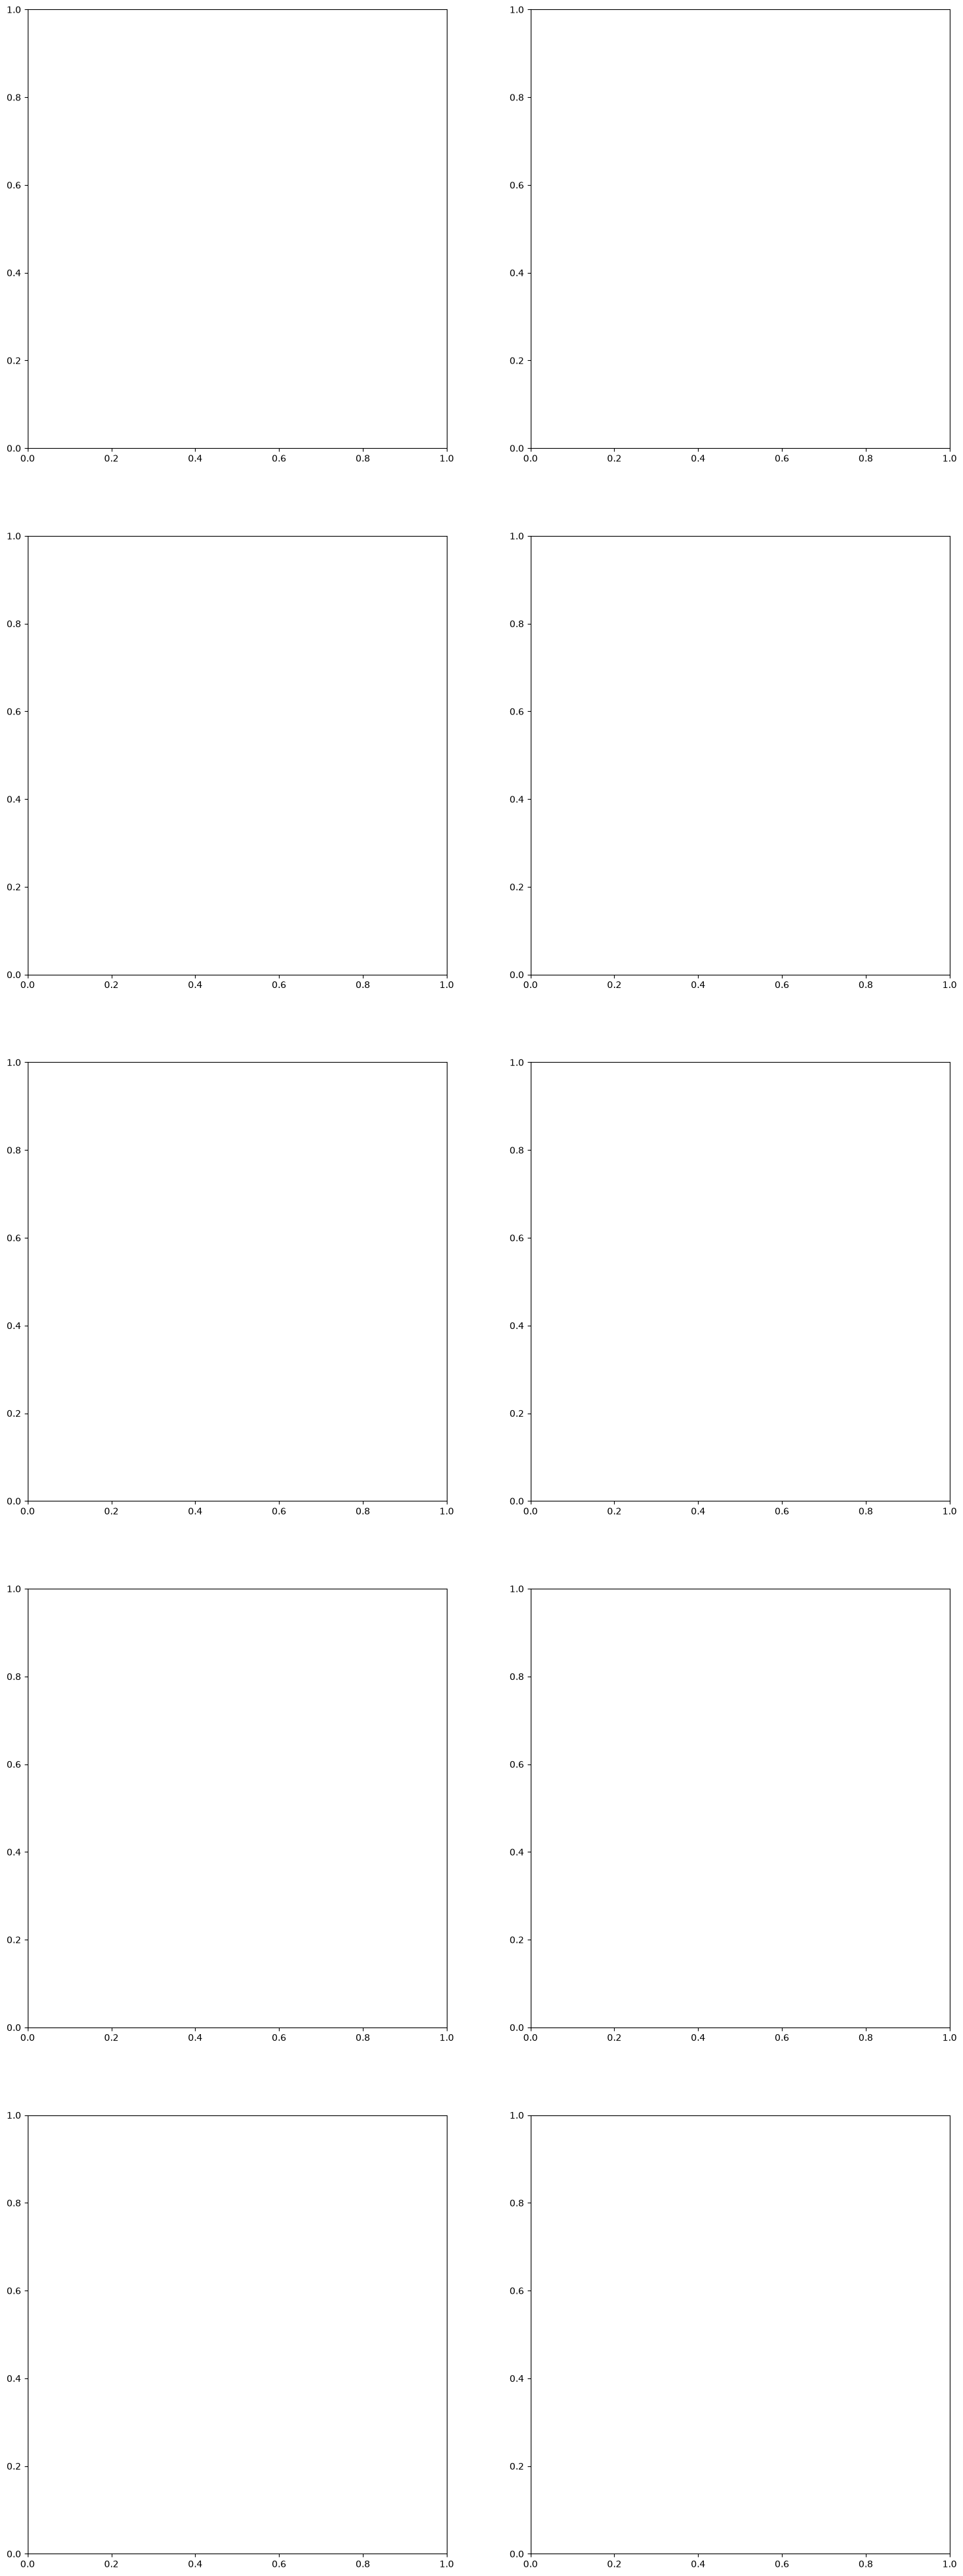

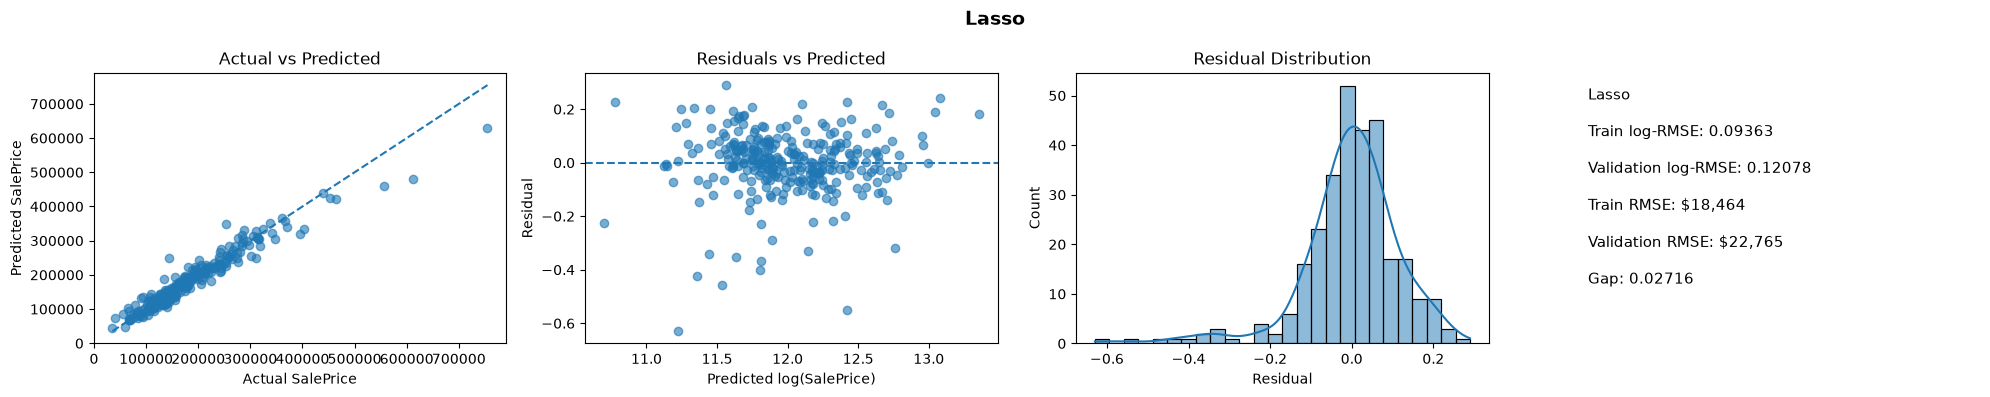

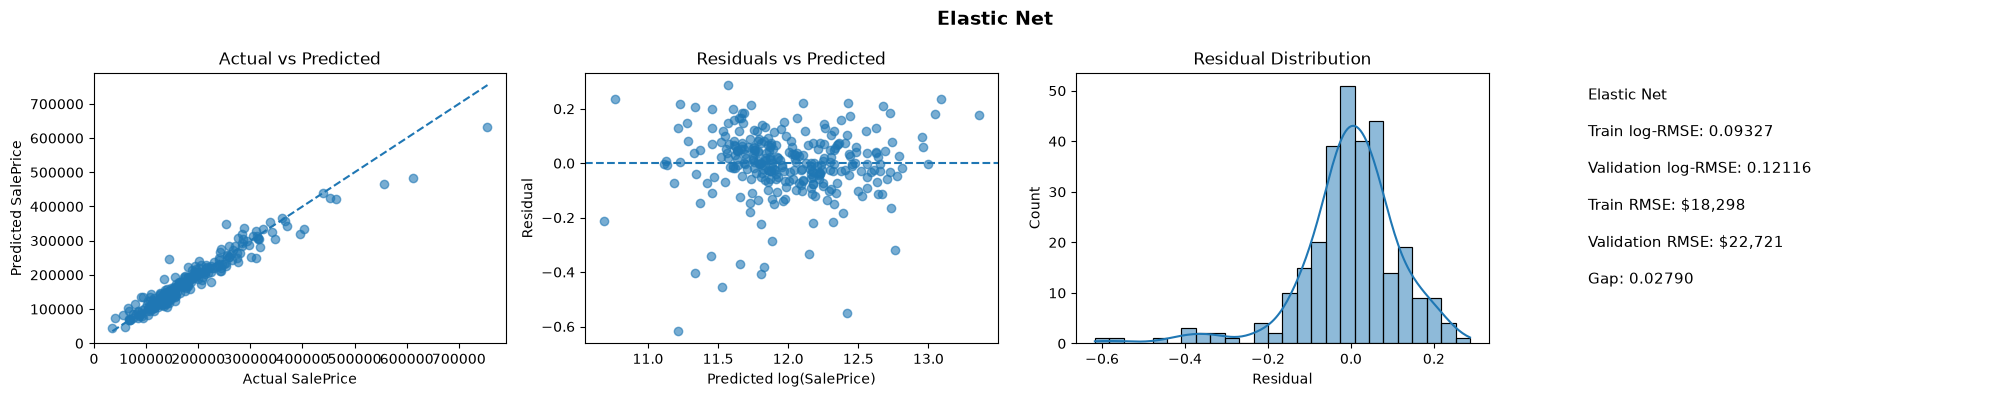

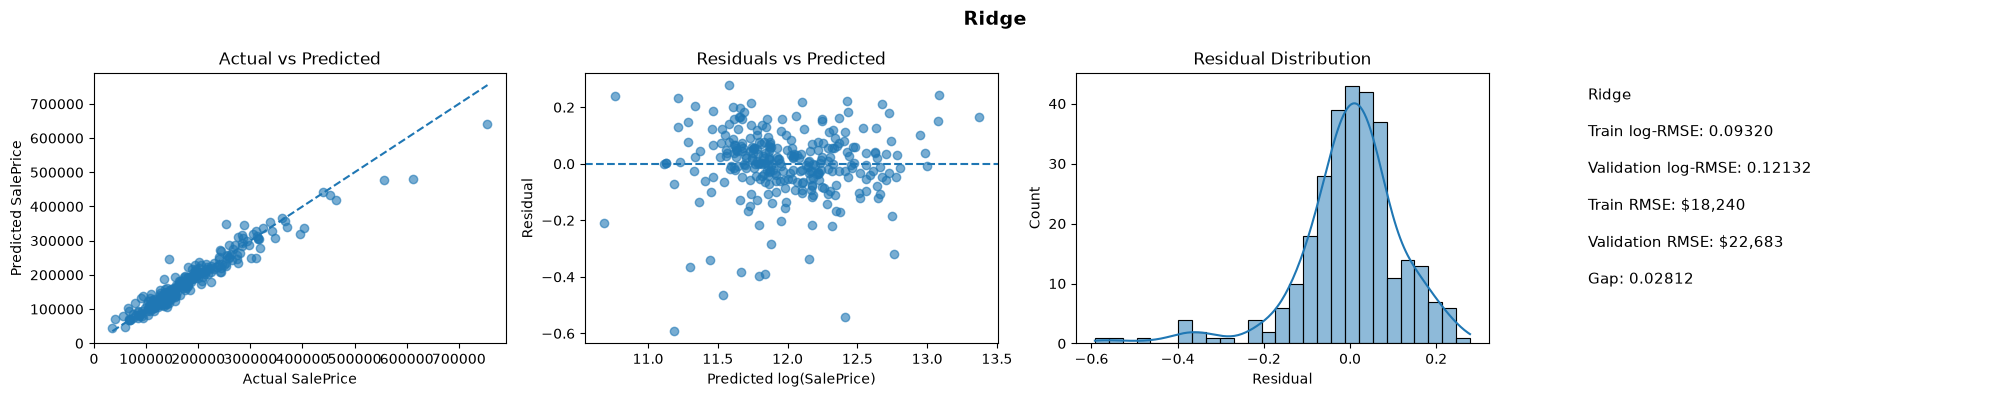

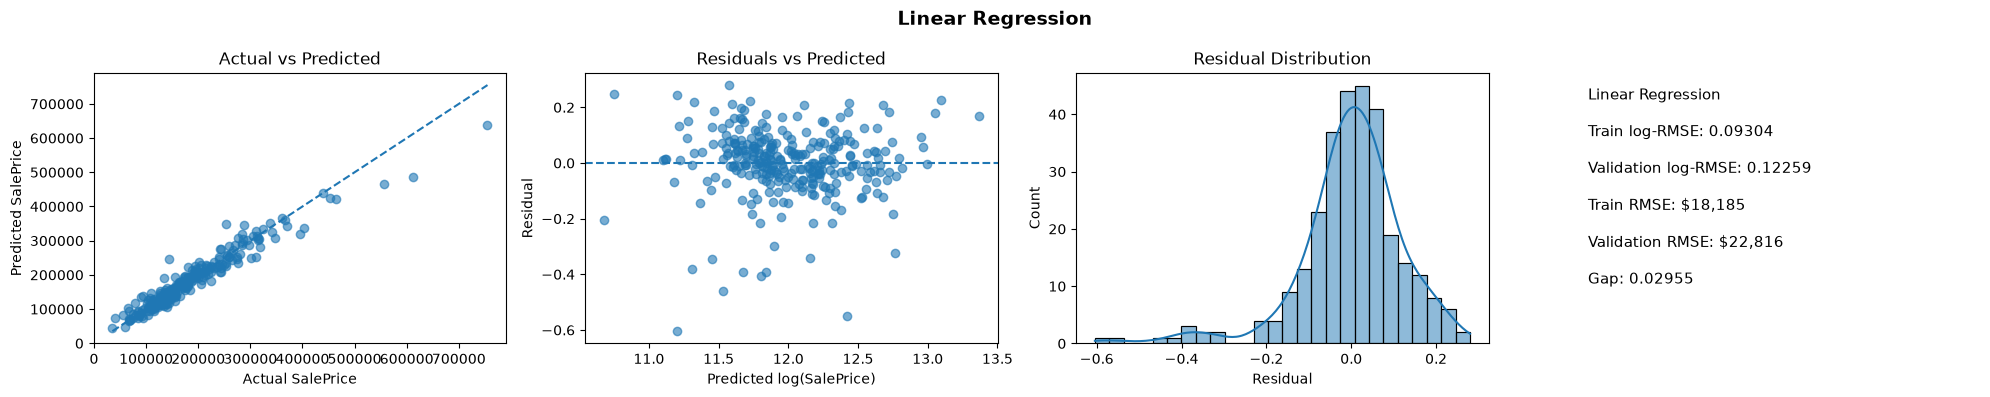

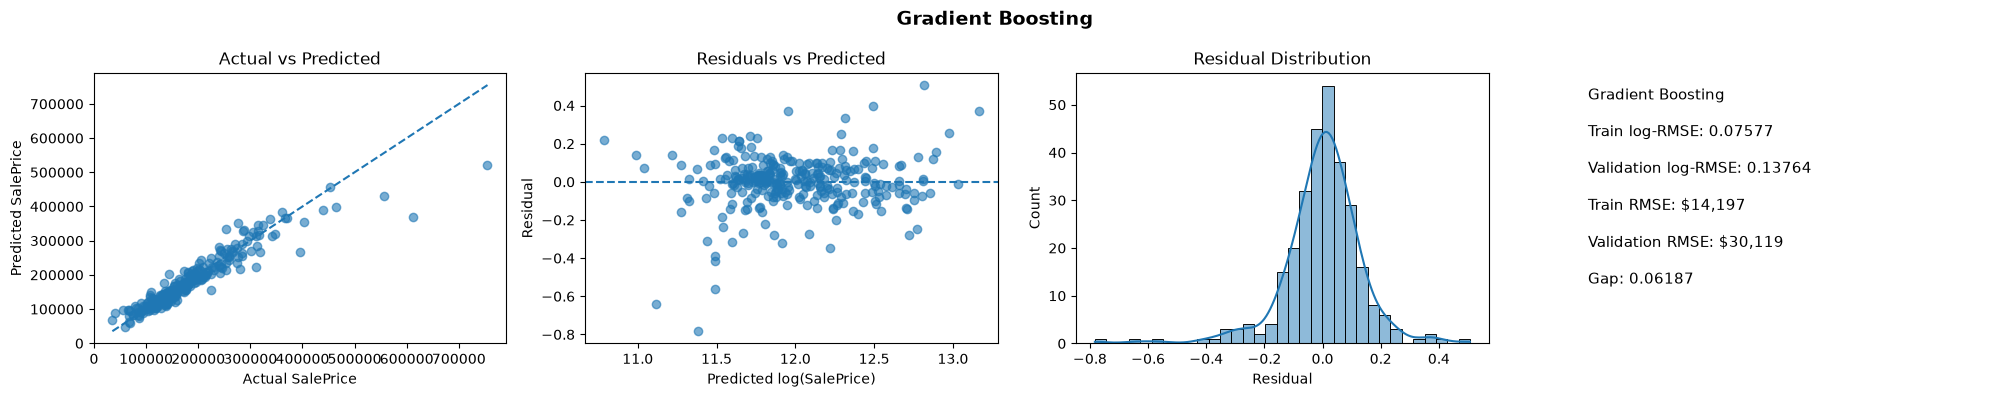

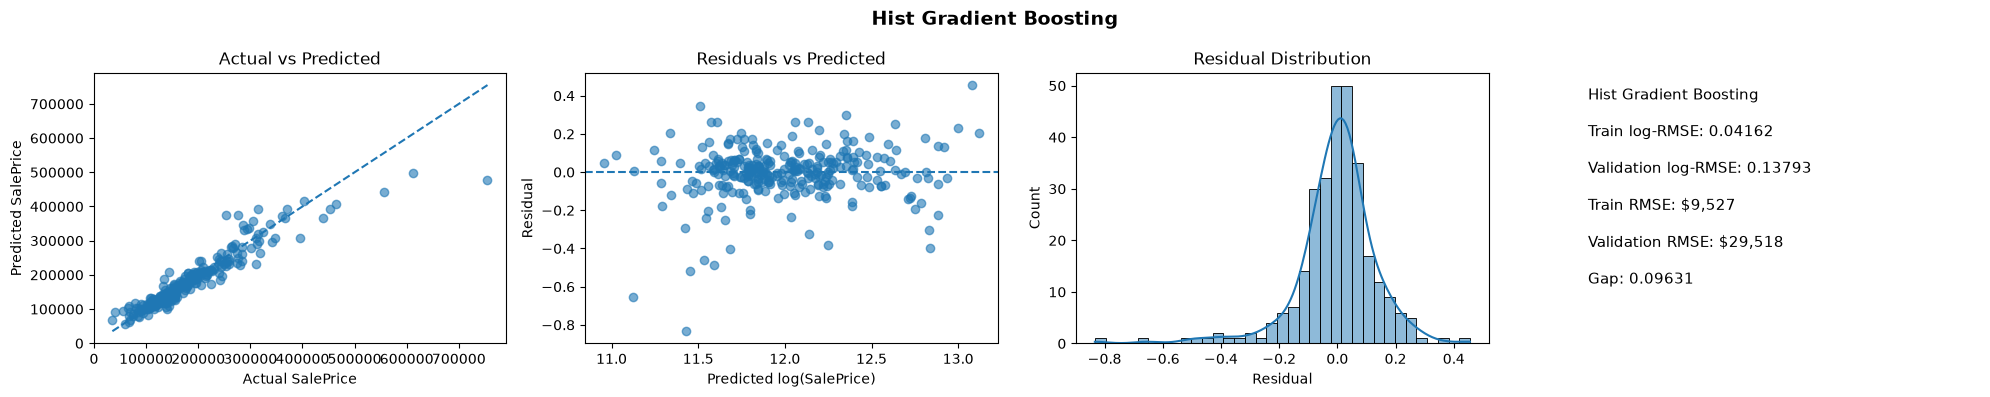

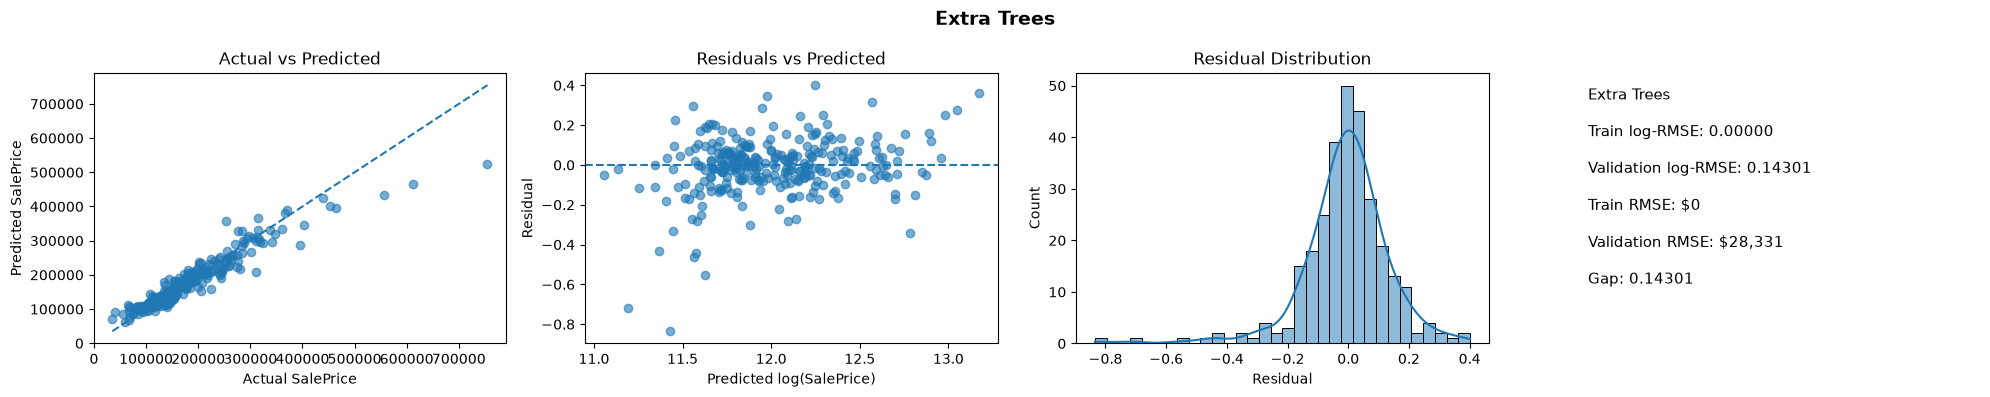

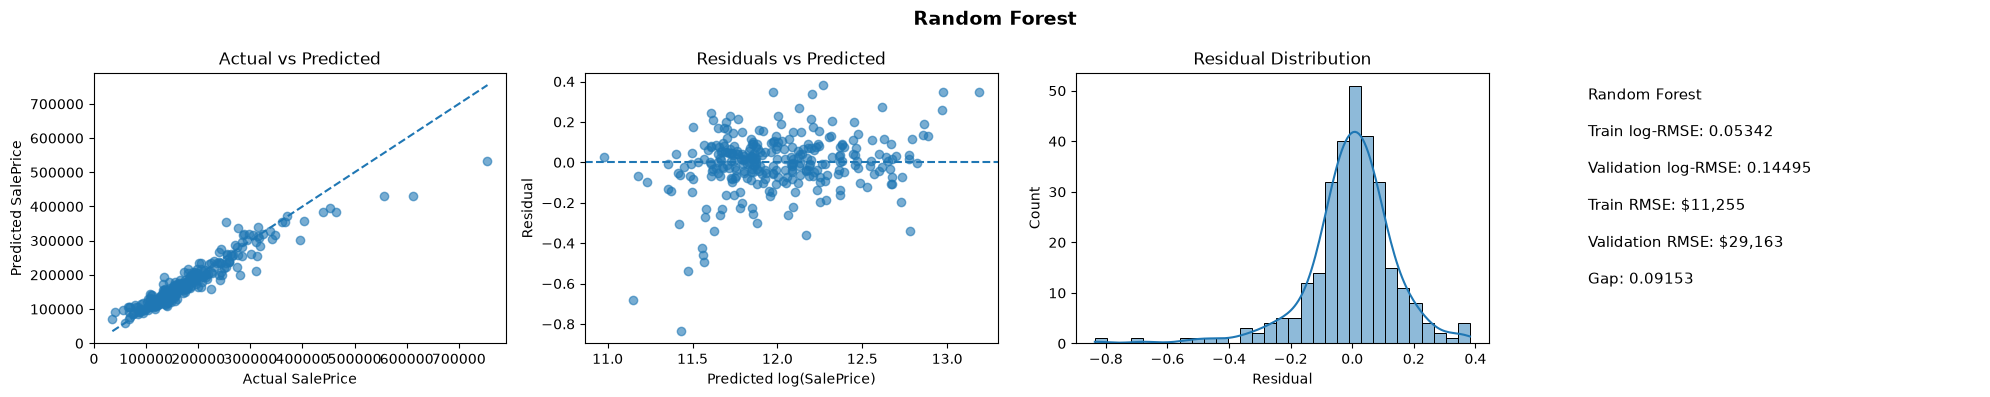

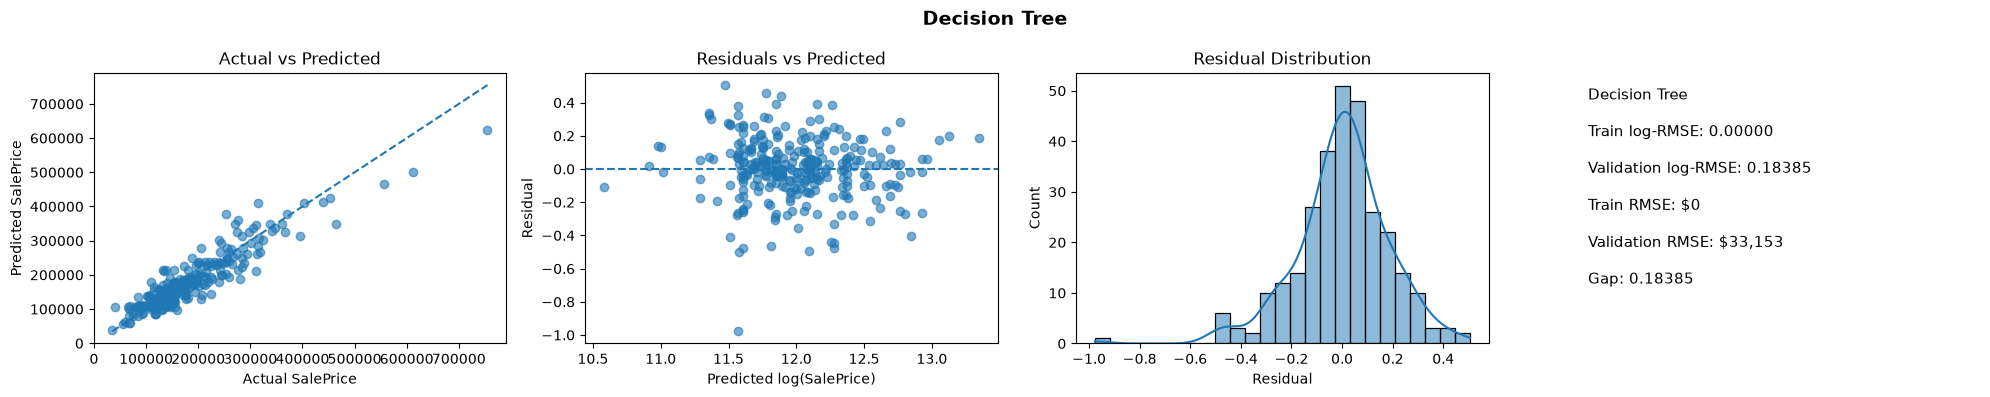

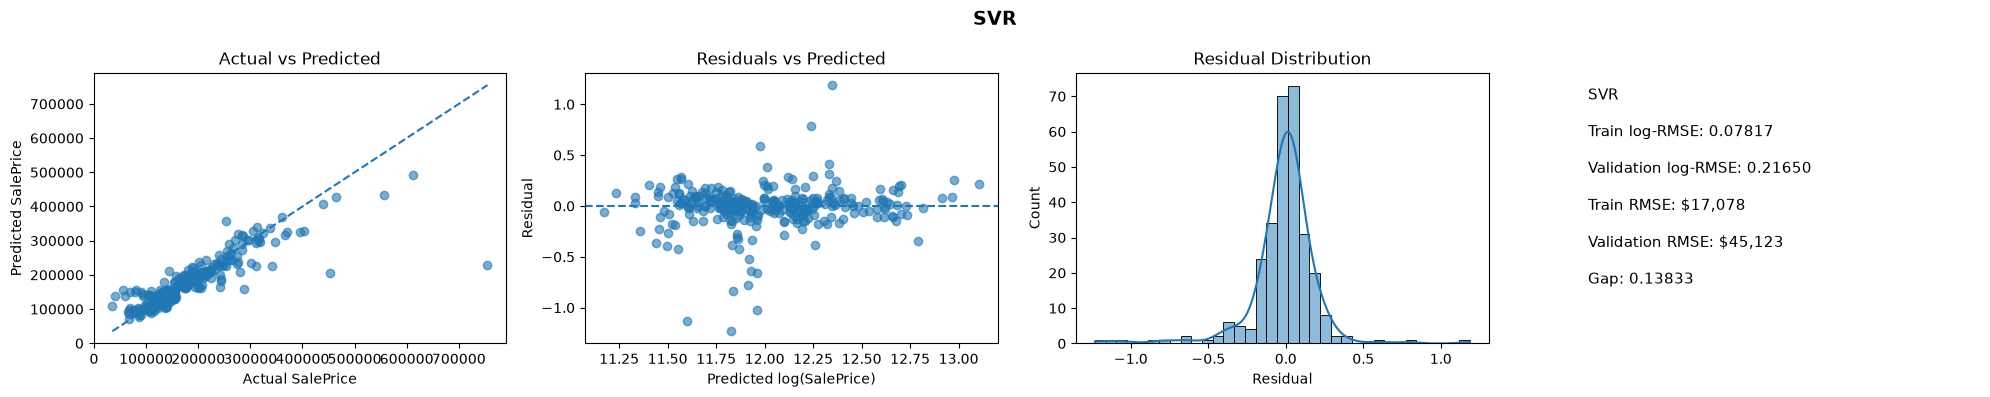

In [62]:
model_names = results_df["Model"].tolist()

models_per_row = 2
rows = int(np.ceil(len(model_names) / models_per_row))

fig, axes = plt.subplots(
    rows,
    models_per_row,
    figsize=(18, rows * 10)
)

axes = np.atleast_2d(axes)

for i, model_name in enumerate(model_names):

    row = i // models_per_row
    col = i % models_per_row

    model_data = model_outputs[model_name]

    y_pred = model_data["predictions"]
    residuals = model_data["residuals"]

    result = results_df[
        results_df["Model"] == model_name
    ].iloc[0]

    # Create one figure for this model
    fig_model, model_axes = plt.subplots(
        1,
        4,
        figsize=(20, 4)
    )

    # -------------------------------------------------
    # 1. Actual vs Predicted
    # -------------------------------------------------

    model_axes[0].scatter(
        np.expm1(y_val),
        np.expm1(y_pred),
        alpha=0.6
    )

    min_value = min(
        np.expm1(y_val).min(),
        np.expm1(y_pred).min()
    )

    max_value = max(
        np.expm1(y_val).max(),
        np.expm1(y_pred).max()
    )

    model_axes[0].plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    model_axes[0].set_title("Actual vs Predicted")
    model_axes[0].set_xlabel("Actual SalePrice")
    model_axes[0].set_ylabel("Predicted SalePrice")

    # -------------------------------------------------
    # 2. Residuals vs Predicted
    # -------------------------------------------------

    model_axes[1].scatter(
        y_pred,
        residuals,
        alpha=0.6
    )

    model_axes[1].axhline(
        0,
        linestyle="--"
    )

    model_axes[1].set_title("Residuals vs Predicted")
    model_axes[1].set_xlabel("Predicted log(SalePrice)")
    model_axes[1].set_ylabel("Residual")

    # -------------------------------------------------
    # 3. Residual Distribution
    # -------------------------------------------------

    sns.histplot(
        residuals,
        kde=True,
        ax=model_axes[2]
    )

    model_axes[2].set_title("Residual Distribution")
    model_axes[2].set_xlabel("Residual")
    model_axes[2].set_ylabel("Count")

    # -------------------------------------------------
    # 4. Metrics
    # -------------------------------------------------

    model_axes[3].axis("off")

    metrics_text = (
        f"{model_name}\n\n"
        f"Train log-RMSE: "
        f"{result['Train log-RMSE']:.5f}\n\n"
        f"Validation log-RMSE: "
        f"{result['Validation log-RMSE']:.5f}\n\n"
        f"Train RMSE: "
        f"${result['Train RMSE']:,.0f}\n\n"
        f"Validation RMSE: "
        f"${result['Validation RMSE']:,.0f}\n\n"
        f"Gap: "
        f"{result['Train/Val Gap']:.5f}"
    )

    model_axes[3].text(
        0.05,
        0.95,
        metrics_text,
        va="top",
        fontsize=11
    )

    fig_model.suptitle(
        model_name,
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

In [63]:
# from sklearn.ensemble import RandomForestRegressor

# rf_model = RandomForestRegressor(
#     n_estimators=100,
#     random_state=42
# )

# rf_result = evaluate_model(
#     rf_model,
#     "Random Forest",
#     X_train,
#     y_train,
#     X_val,
#     y_val
# )

In [64]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import Ridge

# ridge_model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", Ridge(alpha=10.0))
# ])

# ridge_result = evaluate_model(
#     ridge_model,
#     "Ridge Regression",
#     X_train,
#     y_train,
#     X_val,
#     y_val
# )

In [65]:
# from sklearn.ensemble import GradientBoostingRegressor

# gb_model = GradientBoostingRegressor(
#     random_state=42
# )

# gb_result = evaluate_model(
#     gb_model,
#     "Gradient Boosting",
#     X_train,
#     y_train,
#     X_val,
#     y_val
# )